In [3]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [4]:
import json, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# stats
from scipy.stats import ttest_ind, f_oneway, kruskal

# ------------------------
# EDIT THESE
# ------------------------
CACHE_ROOT   = Path("../../outputs/aptos_cache")

RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"
RUN_ID_STAGE3 = "aptos2019_stage3_cd3f6ffabc"
RUN_ID_STAGE4 = "aptos2019_stage4_7741334624"   # <-- your completed stage4 run id

STAGE1_ROOT = CACHE_ROOT / RUN_ID_STAGE1 / "stage1"
STAGE2_ROOT = CACHE_ROOT / RUN_ID_STAGE2 / "stage2"
STAGE3_ROOT = CACHE_ROOT / RUN_ID_STAGE3 / "stage3"
STAGE4_ROOT = CACHE_ROOT / RUN_ID_STAGE4 / "stage4"

assert STAGE4_ROOT.exists(), f"Missing {STAGE4_ROOT}"
print("Stage4 dir:", STAGE4_ROOT)

GROUP_ORDER = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative"]  # APTOS 2019 folders


Stage4 dir: ..\..\outputs\aptos_cache\aptos2019_stage4_7741334624\stage4


In [5]:
def list_stage4_jsons(stage4_root: Path):
    return sorted(stage4_root.glob("*/biomarkers.json"))

paths = list_stage4_jsons(STAGE4_ROOT)
print("stage4 json count:", len(paths))

outs = []
for p in tqdm(paths):
    try:
        outs.append(json.loads(p.read_text()))
    except Exception as e:
        print("[warn] failed reading", p, e)

print("loaded outs:", len(outs))

def get_group(image_id: str) -> str:
    # image_id is like "Severe/img130"
    return (image_id.split("/")[0] if "/" in image_id else "UNKNOWN")

# group them
outs_by_group = {g: [] for g in GROUP_ORDER}
outs_by_group["UNKNOWN"] = []

for o in outs:
    g = get_group(o.get("image_id",""))
    outs_by_group.setdefault(g, []).append(o)

for g in GROUP_ORDER:
    print(g, len(outs_by_group.get(g, [])))
if outs_by_group["UNKNOWN"]:
    print("UNKNOWN:", len(outs_by_group["UNKNOWN"]))





stage4 json count: 3665


100%|██████████| 3665/3665 [00:55<00:00, 65.49it/s]

loaded outs: 3665
No_DR 1808
Mild 370
Moderate 999
Severe 193
Proliferative 295


In [6]:
def flatten_metrics_stage4(o, um_per_px=None):
    """
    Flattens Stage4 'biomarkers.json' into one row:
      - global: FD, density%, tort, caliber
      - rings:  0.5-1.0,1.0-1.5,1.5-2.0,2.0-2.5 (if present)
      - quadrants: I,S,N,T for same 4 metrics (if present)
    """
    bio = o.get("biomarkers") or {}
    g   = bio.get("global") or {}
    rings = bio.get("rings") or {}
    quads = bio.get("quadrants") or {}

    row = {}

    # ---- GLOBAL ----
    row["fractal_dimension"] = float(g.get("fractal_dimension", np.nan))
    row["area_density_pct"]  = 100.0 * float(g.get("area_density", np.nan))
    row["tortuosity_px2"]    = float(g.get("tortuosity_mean", np.nan))

    vco = g.get("vc_orth") or {}
    med_w_px = float(vco.get("median_width", np.nan))
    iqr_w_px = float(vco.get("iqr_width",   np.nan))
    if um_per_px is not None and np.isfinite(med_w_px):
        row["caliber_um"] = med_w_px * um_per_px
    else:
        row["caliber_px"] = med_w_px
    row["median_width_px"] = med_w_px
    row["iqr_width_px"]    = iqr_w_px

    # ---- RINGS ----
    # keep same ring starts as your plots (0.5, 1.0, 1.5, 2.0)
    wanted_starts = [0.5, 1.0, 1.5, 2.0]
    for k, r in rings.items():
        try:
            r0 = float(str(k).split("-")[0])
        except:
            continue
        if r0 not in wanted_starts:
            continue

        row[f"{k}|fractal_dimension"] = float(r.get("fractal_dimension", np.nan))
        row[f"{k}|area_density_pct"]  = 100.0 * float(r.get("area_density", np.nan))
        row[f"{k}|tortuosity_px2"]    = float(r.get("tortuosity_mean", np.nan))

        r_med = float(r.get("median_width", np.nan))
        row[f"{k}|caliber"] = (r_med * um_per_px) if (um_per_px is not None and np.isfinite(r_med)) else r_med
        row[f"{k}|caliber_unit"] = "µm" if um_per_px is not None else "px"

    # ---- QUADRANTS (ISNT) ----
    for Q in ["I","S","N","T"]:
        q = quads.get(Q) or {}
        qg = q.get("global") or {}
        qvco = qg.get("vc_orth") or {}

        row[f"{Q}|fractal_dimension"] = float(qg.get("fractal_dimension", np.nan))
        row[f"{Q}|area_density_pct"]  = 100.0 * float(qg.get("area_density", np.nan))
        row[f"{Q}|tortuosity_px2"]    = float(qg.get("tortuosity_mean", np.nan))

        q_med = float(qvco.get("median_width", np.nan))
        row[f"{Q}|caliber"] = (q_med * um_per_px) if (um_per_px is not None and np.isfinite(q_med)) else q_med

    return row


# Build per-group DataFrames
dfs = {}
for g in GROUP_ORDER:
    arr = [flatten_metrics_stage4(o, um_per_px=None) for o in outs_by_group.get(g, [])]
    dfs[g] = pd.DataFrame(arr)
    print(g, dfs[g].shape)


No_DR (1808, 42)
Mild (370, 42)
Moderate (999, 42)
Severe (193, 42)
Proliferative (295, 42)


In [7]:
def make_summary_table_multi(dfs_by_group: dict, *, um_scale_available=True):
    # decide caliber key
    any_df = next(iter(dfs_by_group.values()))
    cal_key = "caliber_um" if (um_scale_available and "caliber_um" in any_df.columns) else "caliber_px"
    cal_label = "Vascular caliber (µm)" if cal_key == "caliber_um" else "Vascular caliber (px)"

    rows = [
        ("Vascular fractal dimension",   "fractal_dimension"),
        ("Vascular density (%)",         "area_density_pct"),
        ("Vascular tortuosity (px⁻²)",   "tortuosity_px2"),
        (cal_label,                      cal_key),
    ]

    def _fmt(m, s):
        return "—" if (not np.isfinite(m)) else f"{m:.3f} ± {s:.3f}"

    out_rows = []
    for label, key in rows:
        row = {"Retinal vascular parameters": label}
        for g, df in dfs_by_group.items():
            m = float(df[key].mean(skipna=True)) if key in df.columns else np.nan
            s = float(df[key].std(skipna=True))  if key in df.columns else np.nan
            row[g] = _fmt(m, s)
        out_rows.append(row)

    return pd.DataFrame(out_rows)

tbl = make_summary_table_multi({g: dfs[g] for g in GROUP_ORDER})
tbl


,Retinal vascular parameters,No_DR,Mild,Moderate,Severe,Proliferative
0,Vascular fractal dimension,1.403 ± 0.064,1.387 ± 0.060,1.379 ± 0.058,1.348 ± 0.070,1.329 ± 0.080
1,Vascular density (%),7.169 ± 1.916,6.550 ± 1.755,6.288 ± 1.641,5.395 ± 1.581,4.975 ± 1.670
2,Vascular tortuosity (px⁻²),0.179 ± 0.008,0.184 ± 0.009,0.183 ± 0.009,0.182 ± 0.010,0.183 ± 0.010
3,Vascular caliber (px),4.978 ± 0.404,4.803 ± 0.430,4.808 ± 0.391,4.728 ± 0.407,4.623 ± 0.474


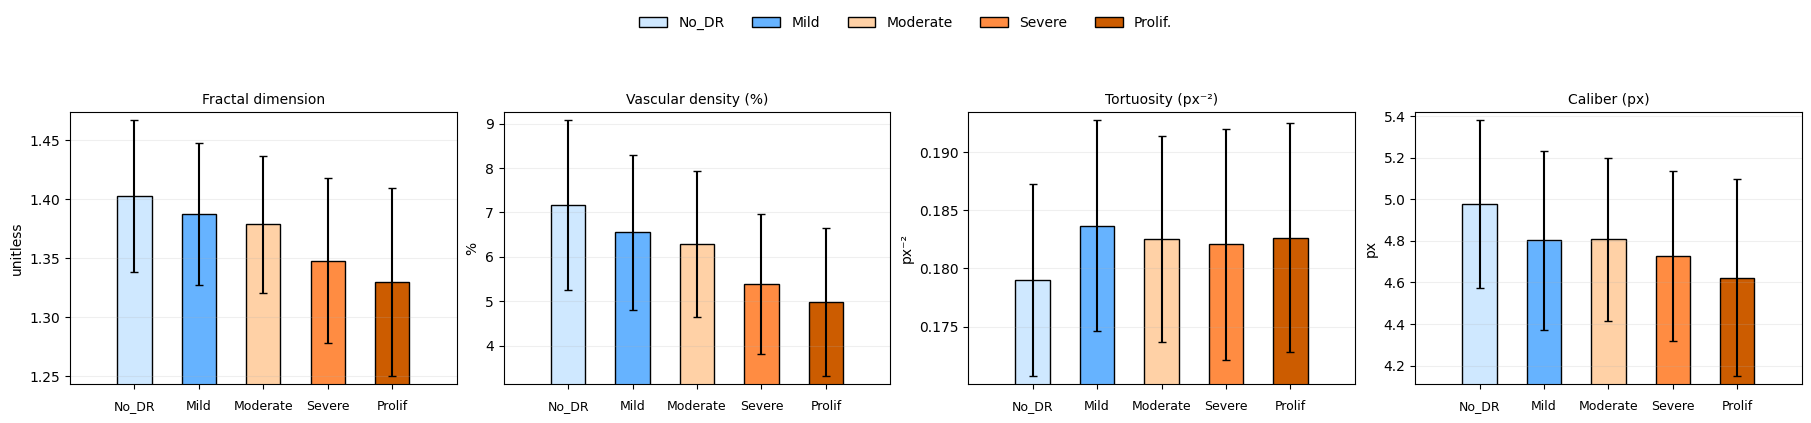

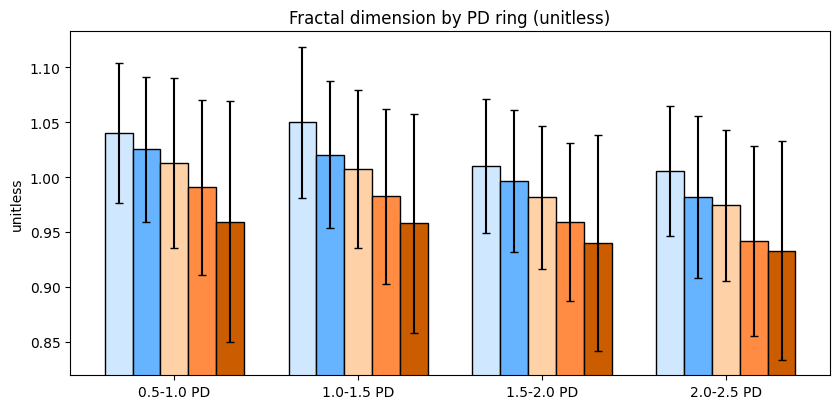

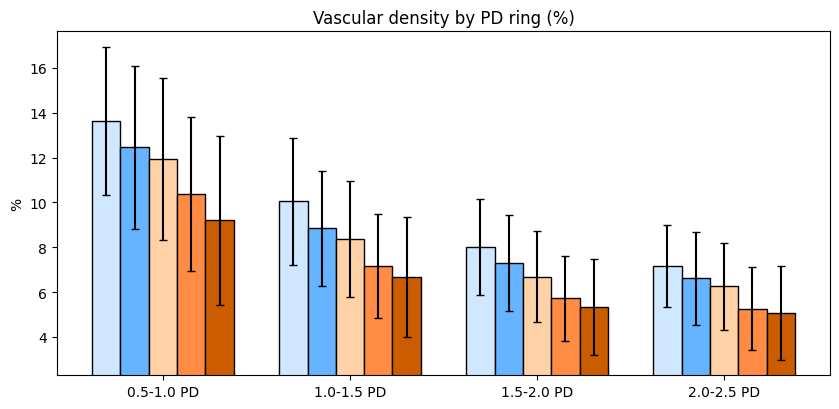

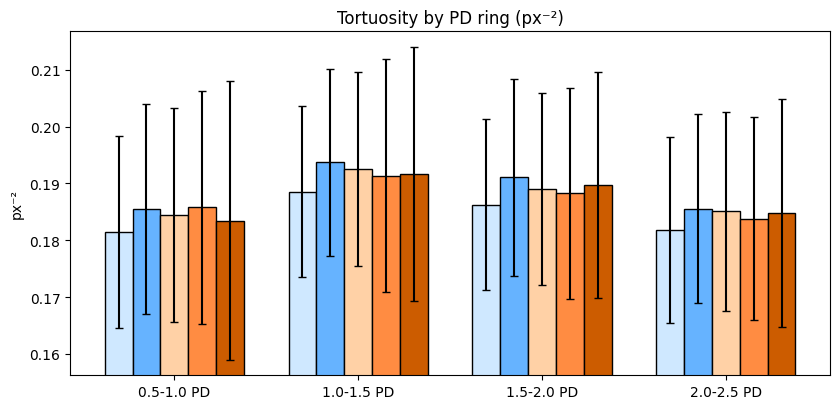

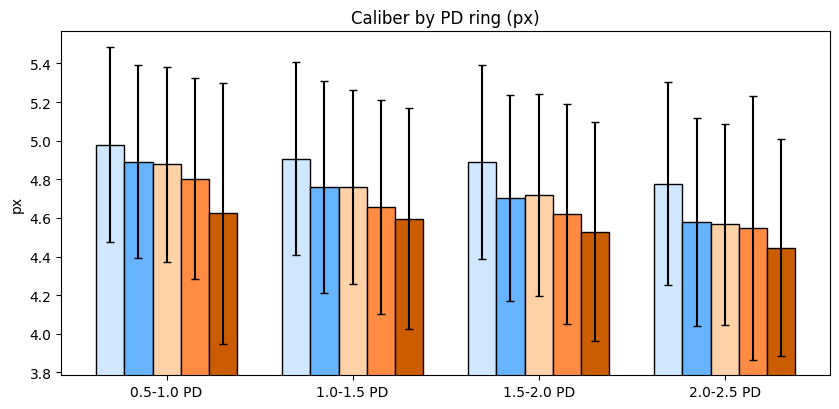

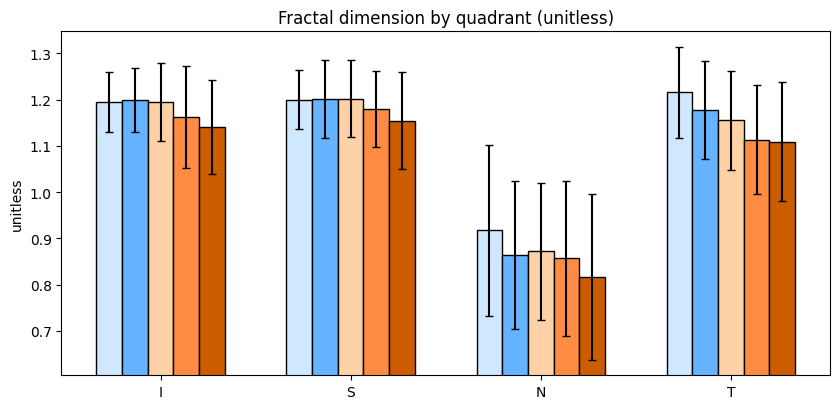

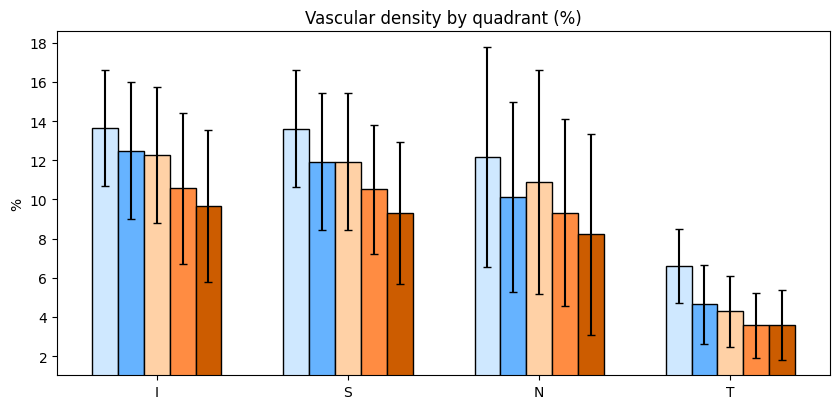

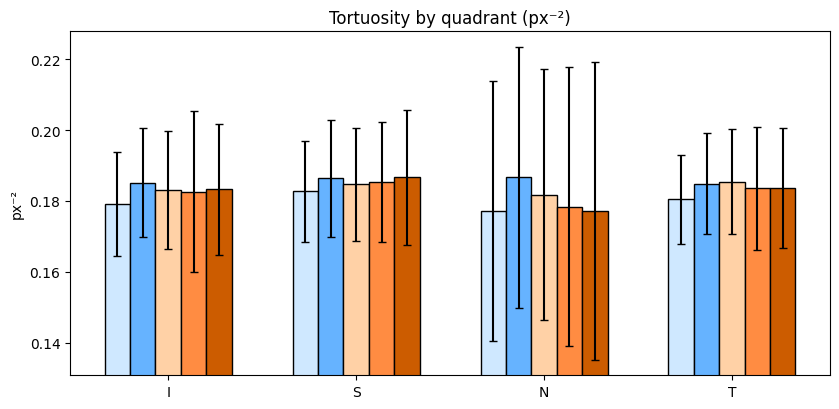

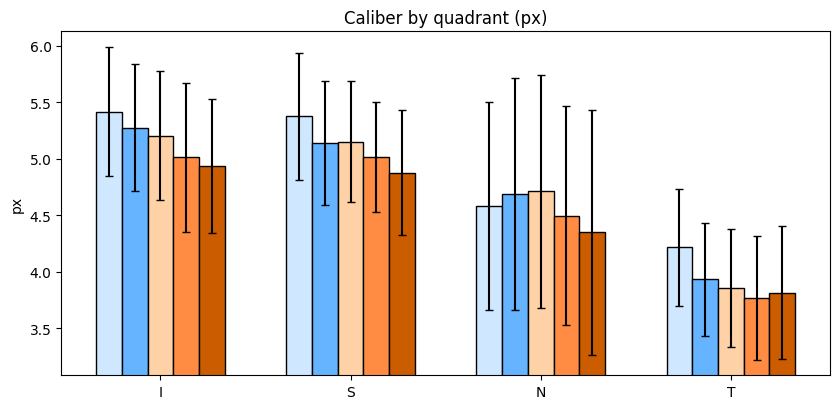

In [8]:
# =========================
# COLORS (edit hex codes here)
# =========================
COLOR_MAP = {
    "No_DR": "#cfe8ff",
    "Mild": "#66b3ff",
    "Moderate": "#ffd1a6",
    "Severe": "#ff8c42",
    "Proliferative": "#cc5c00",
}

# Optional: shorten display labels
def _pretty_group_label(name: str) -> str:
    return "Prolif." if name.lower().startswith("prolif") else name

def _resolve_color_map(groups, color_map=None, default="#999999"):
    """
    groups: list of (gname, df)
    color_map: dict {gname: "#RRGGBB"}
    """
    colors = []
    for gname, _ in groups:
        if color_map and gname in color_map:
            colors.append(color_map[gname])
        else:
            colors.append(default)
    return colors


# =========================
# GLOBAL (FIXED SPACING + CENTERED LABELS + FULL WIDTH USAGE)
# =========================
def bar_global_panels_v4(
    groups, keys, titles_map, ylabels_map,
    figsize=(18, 5),
    bar_width=0.62,      # in x-axis units (since we use a regular grid now)
    x_step=1.55,         # distance between class labels (increase if labels collide)
    x_pad=0.60,          # left/right padding so bars use the whole axis
    ylims=None, ypad_frac=0.03,
    legend_top=True, legend_ncols=5, top_pad_frac=0.18,
    color_map=None, edge_lw=1.0,
    tick_rotation=0, tick_pad=8, tick_fontsize=9,
    label_wrap_map=None  # e.g., {"Proliferative":"Prolifera-\ntive"}
):
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import OrderedDict

    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    try:
        h_in = figsize[1]
        fig.set_constrained_layout_pads(wspace=0.02, hspace=0.02, h_pad=h_in * top_pad_frac)
    except Exception:
        fig.subplots_adjust(top=1.0 - top_pad_frac, wspace=0.02)

    # regular grid positions for groups/classes
    G = len(groups)
    xs = np.arange(G, dtype=float) * x_step

    # ensure bars do not overlap
    bar_width = min(bar_width, x_step * 0.85)

    # colors per group
    colors = _resolve_color_map(groups, color_map=color_map, default="#BBBBBB")

    legend_items = OrderedDict()

    for ax, key in zip(axes, keys):
        means, sds = [], []
        for gname, df in groups:
            m = float(df[key].mean(skipna=True)) if key in df.columns else np.nan
            s = float(df[key].std(skipna=True))  if key in df.columns else np.nan
            means.append(m); sds.append(s)

        for idx, ((gname, _df), x_i, m, s) in enumerate(zip(groups, xs, means, sds)):
            err = None if not np.isfinite(s) else s
            b = ax.bar(
                x_i, m, yerr=err, capsize=3, width=bar_width,
                label=_pretty_group_label(gname),
                color=colors[idx],
                edgecolor="black", linewidth=edge_lw
            )
            if gname not in legend_items:
                legend_items[gname] = b

        # centered labels, with optional wrapping
        labels = []
        for gname, _ in groups:
            lab = _pretty_group_label(gname)
            if label_wrap_map and lab in label_wrap_map:
                lab = label_wrap_map[lab]
            labels.append(lab)

        ax.set_xticks(xs)
        ax.set_xticklabels(labels, rotation=tick_rotation, ha="center", fontsize=tick_fontsize)
        ax.tick_params(axis="x", pad=tick_pad)

        # IMPORTANT: tight x-limits so bars use the full width (fixes “cramped in middle”)
        ax.set_xlim(xs[0] - x_pad, xs[-1] + x_pad)

        ax.set_title(titles_map.get(key, key), fontsize=10)
        ax.set_ylabel(ylabels_map.get(key, "Value"))
        ax.grid(axis="y", alpha=0.2)

        # y zoom
        if isinstance(ylims, dict) and key in ylims and ylims[key] is not None:
            ax.set_ylim(*ylims[key])
        else:
            lows, highs = [], []
            for m, s in zip(means, sds):
                if not np.isfinite(m):
                    continue
                s = 0.0 if not np.isfinite(s) else s
                lows.append(m - s); highs.append(m + s)
            if lows and highs:
                lo, hi = min(lows), max(highs)
                pad = (hi - lo) * ypad_frac if hi > lo else 1.0
                ax.set_ylim(lo - pad, hi + pad)

    # legend (one)
    handles = [legend_items[name] for name in legend_items]
    labels_leg = [_pretty_group_label(name) for name in legend_items.keys()]

    if legend_top:
        fig.legend(handles, labels_leg, loc="upper center",
                   bbox_to_anchor=(0.5, 1.0), ncol=legend_ncols, frameon=False)
    else:
        fig.legend(handles, labels_leg, loc="upper right", frameon=False)

    return fig, axes


# =========================
# PD RINGS (FIXED: MORE SPACING BETWEEN RING GROUPS)
# =========================
def bar_rings_v4(
    groups, suffix, title, ylabel,
    bar_width=0.11,
    intra_sep=0.0,     # spacing BETWEEN classes inside same ring
    ring_gap=1.85,      # spacing BETWEEN ring clusters (increase if still close)
    ylims=None, ypad_frac=0.05,
    color_map=None,
    edge_lw=1.0
):
    import numpy as np, matplotlib.pyplot as plt

    def _ring_columns(df, suffix):
        cols = [c for c in df.columns if c.endswith("|"+suffix)]
        keyed=[]
        for c in cols:
            try:
                r0 = float(c.split("|")[0].split("-")[0])
                keyed.append((r0, c))
            except:
                pass
        return [c for _,c in sorted(keyed)]

    cols_all = [_ring_columns(df, suffix) for _, df in groups]
    cols = set(cols_all[0])
    for c in cols_all[1:]:
        cols = cols.intersection(c)
    cols = sorted(list(cols), key=lambda s: float(s.split("|")[0].split("-")[0]))
    if not cols:
        print(f"[warn] no common ring columns for '{suffix}'")
        return

    ring_labels = [c.split("|")[0].replace("PD"," PD") for c in cols]

    means = []; sds = []
    for _, df in groups:
        means.append(df[cols].mean(skipna=True).values.astype(float))
        sds.append(df[cols].std(skipna=True).values.astype(float))

    colors = _resolve_color_map(groups, color_map=color_map, default="#BBBBBB")

    nR = len(cols)
    base = np.arange(nR, dtype=float) * ring_gap  # <-- key fix: separate ring clusters

    K = len(groups)
    offs = (np.arange(K) - (K - 1) / 2.0) * (bar_width + intra_sep)  # <-- spacing within ring

    plt.figure(figsize=(max(8.5, 2.0 * nR), 4.2))

    for k,(gname,_df) in enumerate(groups):
        y = np.asarray(means[k], dtype=float)
        e = np.nan_to_num(np.asarray(sds[k], dtype=float), nan=0.0)
        plt.bar(base + offs[k], y, yerr=e, capsize=3,
                width=bar_width, label=_pretty_group_label(gname),
                color=colors[k], edgecolor="black", linewidth=edge_lw)

    plt.xticks(base, ring_labels)
    plt.ylabel(ylabel); plt.title(title)
    #plt.legend(); plt.grid(axis="y", alpha=0.2)

    if ylims is not None:
        plt.ylim(*ylims)
    else:
        lows_list  = []
        highs_list = []
        for m, s in zip(means, sds):
            m = np.asarray(m, dtype=float)
            s = np.nan_to_num(np.asarray(s, dtype=float), nan=0.0)
            lows_list.append(m - s)
            highs_list.append(m + s)
        lo = float(np.nanmin(np.concatenate(lows_list)))
        hi = float(np.nanmax(np.concatenate(highs_list)))
        pad = (hi - lo) * ypad_frac if hi > lo else 1.0
        plt.ylim(lo - pad, hi + pad)

    plt.tight_layout(); plt.show()


# =========================
# ISNT QUADRANTS (already ok, but uses COLOR_MAP + outlines)
# =========================
def bar_quadrants_v1(
    groups, suffix, title, ylabel,
    bar_width=0.11,
    group_gap=1.35,
    ylims=None, ypad_frac=0.05,
    color_map=None,
    edge_lw=1.0
):
    import numpy as np
    import matplotlib.pyplot as plt

    quads = ["I", "S", "N", "T"]
    cols  = [f"{q}|{suffix}" for q in quads]
    cols  = [c for c in cols if all(c in df.columns for _, df in groups)]
    if not cols:
        print(f"[warn] no common quadrant columns for '{suffix}'")
        return

    means, sds = [], []
    for _, df in groups:
        arr = df[cols].astype(float)
        means.append(arr.mean(skipna=True).values)
        sds.append(arr.std(skipna=True).values)

    nQ = len(cols)
    base = np.arange(nQ, dtype=float) * group_gap
    K = len(groups)
    offs = (np.arange(K) - (K - 1) / 2.0) * bar_width
    quad_labels = [c.split("|")[0] for c in cols]

    colors = _resolve_color_map(groups, color_map=color_map, default="#BBBBBB")

    plt.figure(figsize=(max(8.5, 2.0 * nQ), 4.2))
    for k, (gname, _df) in enumerate(groups):
        y = np.asarray(means[k], dtype=float)
        e = np.nan_to_num(np.asarray(sds[k], dtype=float), nan=0.0)
        plt.bar(base + offs[k], y, yerr=e, capsize=3,
                width=bar_width, label=_pretty_group_label(gname),
                color=colors[k], edgecolor="black", linewidth=edge_lw)

    plt.xticks(base, quad_labels)
    plt.ylabel(ylabel); plt.title(title)
    #plt.legend(); plt.grid(axis="y", alpha=0.2)

    if ylims is not None:
        plt.ylim(*ylims)
    else:
        lows, highs = [], []
        for y, e in zip(means, sds):
            y = np.asarray(y, float); e = np.nan_to_num(np.asarray(e, float), nan=0.0)
            low  = (y - e)[np.isfinite(y - e)]
            high = (y + e)[np.isfinite(y + e)]
            if low.size:  lows.append(low)
            if high.size: highs.append(high)
        if lows and highs:
            lo = float(np.min(np.concatenate(lows)))
            hi = float(np.max(np.concatenate(highs)))
            pad = (hi - lo) * ypad_frac if hi > lo else 1.0
            plt.ylim(lo - pad, hi + pad)

    plt.tight_layout(); plt.show()


# =========================
# USE IT (same as before)
# =========================
groups = [(g, dfs[g]) for g in GROUP_ORDER]

cal_key = "caliber_um" if "caliber_um" in dfs[GROUP_ORDER[0]].columns else "caliber_px"
keys = ["fractal_dimension", "area_density_pct", "tortuosity_px2", cal_key]

titles_map = {
    "fractal_dimension": "Fractal dimension",
    "area_density_pct":  "Vascular density (%)",
    "tortuosity_px2":    "Tortuosity (px⁻²)",
    cal_key:             "Caliber (µm)" if cal_key == "caliber_um" else "Caliber (px)",
}
ylabels_map = {
    "fractal_dimension": "unitless",
    "area_density_pct":  "%",
    "tortuosity_px2":    "px⁻²",
    cal_key:             ("µm" if cal_key == "caliber_um" else "px"),
}

# If "Severe" and "Prolif." are still close, wrap the prolif label:
LABEL_WRAP = {"Prolif.": "Prolif"}

bar_global_panels_v4(
    groups=groups,
    keys=keys,
    titles_map=titles_map,
    ylabels_map=ylabels_map,
    color_map=COLOR_MAP,
    x_step=0.75,        # spacing between classes (increase if needed)
    x_pad=0.75,         # left/right breathing room
    bar_width=0.4,
    tick_rotation=0,
    label_wrap_map=LABEL_WRAP,
    legend_ncols=5
)

# rings
unit = "µm" if cal_key == "caliber_um" else "px"
bar_rings_v4(groups, "fractal_dimension", "Fractal dimension by PD ring (unitless)", "unitless",
            bar_width=0.28, ring_gap=1.85, color_map=COLOR_MAP)
bar_rings_v4(groups, "area_density_pct",  "Vascular density by PD ring (%)", "%",
            bar_width=0.28, ring_gap=1.85, color_map=COLOR_MAP)
bar_rings_v4(groups, "tortuosity_px2",    "Tortuosity by PD ring (px⁻²)", "px⁻²",
            bar_width=0.28, ring_gap=1.85, color_map=COLOR_MAP)
bar_rings_v4(groups, "caliber",           f"Caliber by PD ring ({unit})", unit,
            bar_width=0.28, ring_gap=1.85, color_map=COLOR_MAP)

# quadrants
bar_quadrants_v1(groups, "fractal_dimension", "Fractal dimension by quadrant (unitless)", "unitless",
                bar_width=0.25, group_gap=1.85, color_map=COLOR_MAP)
bar_quadrants_v1(groups, "area_density_pct",  "Vascular density by quadrant (%)", "%",
                bar_width=0.25, group_gap=1.85, color_map=COLOR_MAP)
bar_quadrants_v1(groups, "tortuosity_px2",    "Tortuosity by quadrant (px⁻²)", "px⁻²",
                bar_width=0.25, group_gap=1.85, color_map=COLOR_MAP)
bar_quadrants_v1(groups, "caliber",           f"Caliber by quadrant ({unit})", unit,
                bar_width=0.25, group_gap=1.85, color_map=COLOR_MAP)


#new

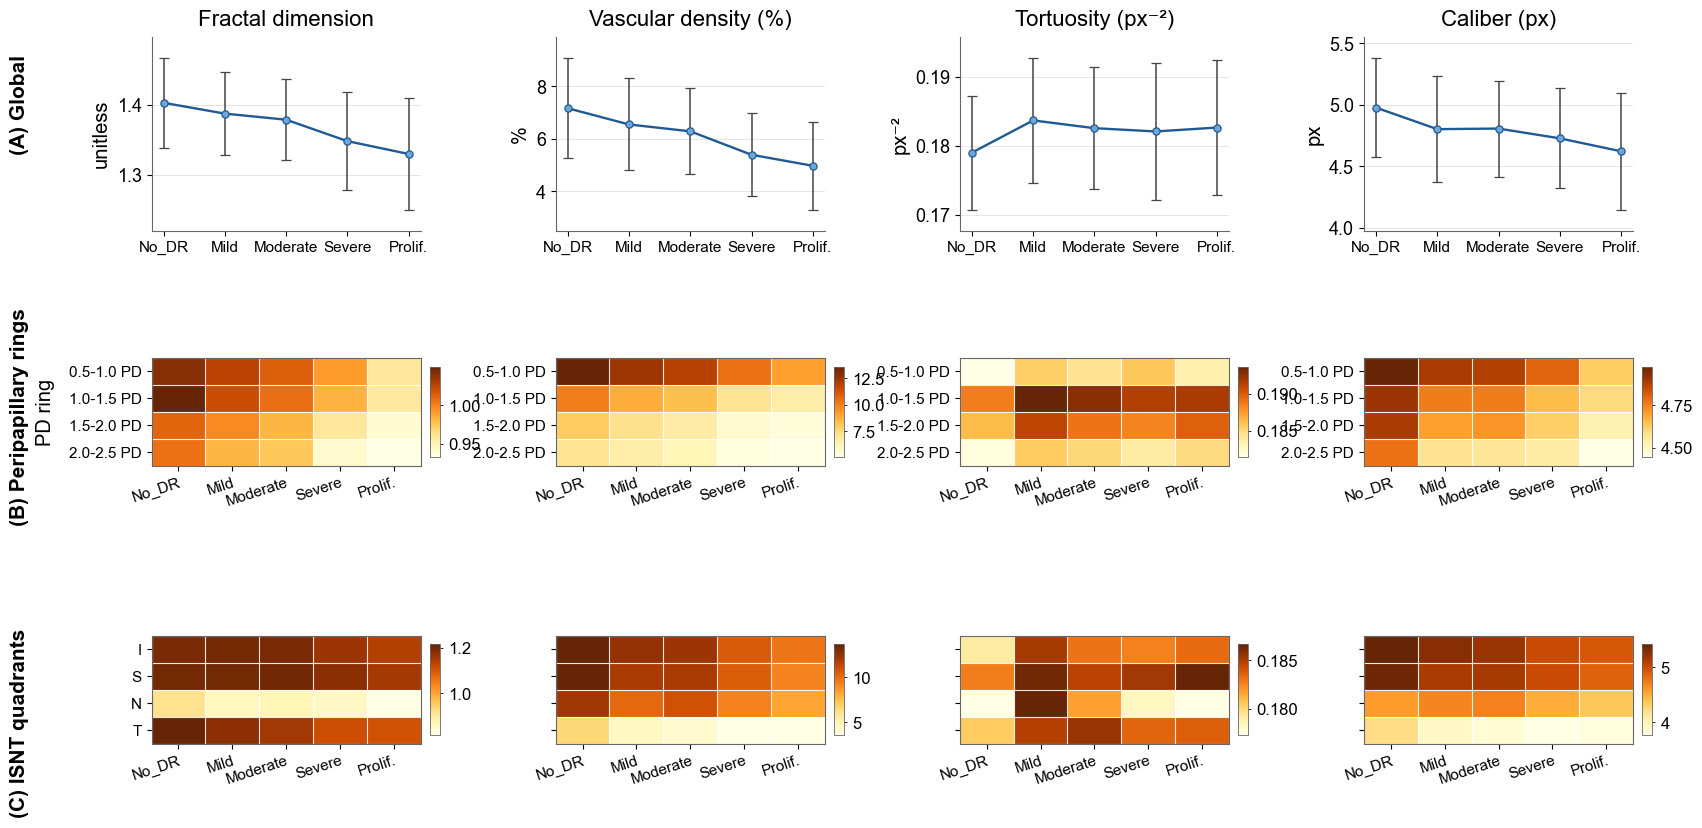

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================================================
# GLOBAL STYLE
# =========================================================
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": ["Arial", "sans-serif"],
    "font.size": 13.5,
    "axes.titlesize": 16,
    "axes.titleweight": "regular",
    "axes.labelsize": 14.5,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.2,
})

# =========================================================
# HELPERS
# =========================================================
def _get_global_stats(groups, key):
    means, sds = [], []
    for _, df in groups:
        means.append(float(df[key].mean(skipna=True)) if key in df.columns else np.nan)
        sds.append(float(df[key].std(skipna=True)) if key in df.columns else np.nan)
    return np.array(means, dtype=float), np.array(sds, dtype=float)

def _common_ring_cols(groups, suffix):
    def _ring_columns(df, suffix):
        cols = [c for c in df.columns if c.endswith("|" + suffix)]
        keyed = []
        for c in cols:
            try:
                r0 = float(c.split("|")[0].split("-")[0])
                keyed.append((r0, c))
            except Exception:
                pass
        return [c for _, c in sorted(keyed)]

    cols_all = [_ring_columns(df, suffix) for _, df in groups]
    cols = set(cols_all[0])
    for c in cols_all[1:]:
        cols = cols.intersection(c)
    return sorted(list(cols), key=lambda s: float(s.split("|")[0].split("-")[0]))

def _common_quad_cols(groups, suffix):
    quads = ["I", "S", "N", "T"]
    cols = [f"{q}|{suffix}" for q in quads]
    return [c for c in cols if all(c in df.columns for _, df in groups)]

def _matrix_from_cols(groups, cols):
    mat = []
    for c in cols:
        row = []
        for _, df in groups:
            row.append(float(df[c].mean(skipna=True)) if c in df.columns else np.nan)
        mat.append(row)
    return np.array(mat, dtype=float)

def _pretty_ring_label(c):
    return c.split("|")[0].replace("PD", " PD")

def _pretty_quad_label(c):
    return c.split("|")[0]

def _short_group_label(name):
    low = name.lower()
    if low.startswith("prolif"):
        return "Prolif."
    if low == "moderate":
        return "Moderate"
    if low == "no_dr":
        return "No_DR"
    return name

def _clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#666666")
    ax.spines["bottom"].set_color("#666666")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

def _add_inset_colorbar(ax, im):
    cax = inset_axes(
        ax,
        width="3.6%",
        height="84%",
        loc="center right",
        borderpad=-1.0
    )
    cbar = plt.colorbar(im, cax=cax)
    cbar.outline.set_linewidth(0.6)
    cbar.outline.set_edgecolor("#666666")
    cbar.ax.tick_params(labelsize=12, length=2.5, width=0.6)

# =========================================================
# DRAW GLOBAL PANELS
# =========================================================
def _draw_global_panel(ax, groups, key, ylabel, title=None):
    x = np.arange(len(groups))
    xticks = [_short_group_label(g) for g, _ in groups]
    means, sds = _get_global_stats(groups, key)

    ax.errorbar(
        x, means, yerr=sds,
        fmt="o-", color="#1f5a94",
        ecolor="#444444",
        lw=1.7, elinewidth=1.1,
        capsize=3.5, capthick=1.0,
        markersize=5.2,
        markerfacecolor="#6ea6d7",
        markeredgecolor="#1f5a94",
        markeredgewidth=0.9,
        zorder=3
    )

    if title is not None:
        ax.set_title(title, pad=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xticks, fontsize=11, rotation=18, ha="right", rotation_mode="anchor")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color="#d9d9d9", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    _clean_axis(ax)

    # makes top-row panels more square-ish
    ax.set_box_aspect(0.72)

    finite = np.isfinite(means) & np.isfinite(sds)
    if finite.any():
        lo = np.min(means[finite] - sds[finite])
        hi = np.max(means[finite] + sds[finite])
        pad = (hi - lo) * 0.14 if hi > lo else 1.0
        ax.set_ylim(lo - pad, hi + pad)

# =========================================================
# DRAW HEATMAP PANELS
# =========================================================
def _draw_heatmap(ax, groups, suffix, region_kind="ring", ylabel=None, show_ylabels=True, show_title=None):
    if region_kind == "ring":
        cols = _common_ring_cols(groups, suffix)
        ylabels = [_pretty_ring_label(c) for c in cols]
    else:
        cols = _common_quad_cols(groups, suffix)
        ylabels = [_pretty_quad_label(c) for c in cols]

    if not cols:
        ax.axis("off")
        return

    mat = _matrix_from_cols(groups, cols)
    xticks = [_short_group_label(g) for g, _ in groups]

    finite = mat[np.isfinite(mat)]
    vmin = float(finite.min())
    vmax = float(finite.max())

    im = ax.imshow(
        mat,
        aspect="auto",
        cmap="YlOrBr",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    if show_title is not None:
        ax.set_title(show_title, pad=6)

    ax.set_xticks(np.arange(len(xticks)))
    ax.set_xticklabels(xticks, fontsize=11, rotation=18, ha="right", rotation_mode="anchor")

    ax.set_yticks(np.arange(len(ylabels)))
    if show_ylabels:
        ax.set_yticklabels(ylabels, fontsize=11)
    else:
        ax.set_yticklabels([])

    if ylabel:
        ax.set_ylabel(ylabel, labelpad=10)

    # subtle cell boundaries
    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8, alpha=0.9)
    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(0.8)

    # box aspect close to 4/5 so 4x5 heatmaps look squarer
    ax.set_box_aspect(0.40)

    _add_inset_colorbar(ax, im)

# =========================================================
# MAIN FIGURE: 3 x 4
# =========================================================
def make_biomarker_summary_figure_compact_3x4(
    groups,
    cal_key="caliber_px",
    figsize=(16.5, 10.5)
):
    fig, axes = plt.subplots(3, 4, figsize=(16.5, 9.3))

    col_titles = [
        "Fractal dimension",
        "Vascular density (%)",
        "Tortuosity (px⁻²)",
        "Caliber (µm)" if cal_key == "caliber_um" else "Caliber (px)",
    ]

    # -------------------------
    # ROW 1: GLOBAL
    # -------------------------
    _draw_global_panel(axes[0, 0], groups, "fractal_dimension", "unitless", title=col_titles[0])
    _draw_global_panel(axes[0, 1], groups, "area_density_pct", "%",        title=col_titles[1])
    _draw_global_panel(axes[0, 2], groups, "tortuosity_px2", "px⁻²",       title=col_titles[2])
    _draw_global_panel(
        axes[0, 3], groups, cal_key,
        "µm" if cal_key == "caliber_um" else "px",
        title=col_titles[3]
    )

    # -------------------------
    # ROW 2: PD RINGS
    # -------------------------
    _draw_heatmap(axes[1, 0], groups, "fractal_dimension", region_kind="ring", ylabel="PD ring", show_ylabels=True)
    _draw_heatmap(axes[1, 1], groups, "area_density_pct",  region_kind="ring", ylabel=None, show_ylabels=True)
    _draw_heatmap(axes[1, 2], groups, "tortuosity_px2",    region_kind="ring", ylabel=None, show_ylabels=True)
    _draw_heatmap(axes[1, 3], groups, "caliber",           region_kind="ring", ylabel=None, show_ylabels=True)

    # -------------------------
    # ROW 3: ISNT QUADRANTS
    # -------------------------
    _draw_heatmap(axes[2, 0], groups, "fractal_dimension", region_kind="quad", ylabel=None, show_ylabels=True)
    _draw_heatmap(axes[2, 1], groups, "area_density_pct",  region_kind="quad", ylabel=None,       show_ylabels=False)
    _draw_heatmap(axes[2, 2], groups, "tortuosity_px2",    region_kind="quad", ylabel=None,       show_ylabels=False)
    _draw_heatmap(axes[2, 3], groups, "caliber",           region_kind="quad", ylabel=None,       show_ylabels=False)

    # -------------------------
    # LEFT-SIDE ROW LABELS
    # -------------------------
    fig.text(0.010, 0.84, "(A) Global", rotation=90, fontsize=15, fontweight="bold",
         va="center", ha="center")
    fig.text(0.010, 0.505, "(B) Peripapillary rings", rotation=90, fontsize=15, fontweight="bold",
            va="center", ha="center")
    fig.text(0.010, 0.175, "(C) ISNT quadrants", rotation=90, fontsize=15, fontweight="bold",
            va="center", ha="center")

    fig.subplots_adjust(
        left=0.090,
        right=0.988,
        top=0.94,
        bottom=0.08,
        hspace=0.14,
        wspace=0.5
    )

    return fig, axes

# =========================================================
# USE IT
# =========================================================
groups = [(g, dfs[g]) for g in GROUP_ORDER]
cal_key = "caliber_um" if "caliber_um" in dfs[GROUP_ORDER[0]].columns else "caliber_px"

fig, axes = make_biomarker_summary_figure_compact_3x4(
    groups=groups,
    cal_key=cal_key,
    figsize=(16.5, 10.5)
)

# Optional save
# plt.savefig("biomarker_summary_3x4_compact.png", dpi=300, bbox_inches="tight")

plt.show()

In [15]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from IPython.display import display

# =========================
# CONFIG
# =========================
GROUP_ORDER = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative"]

GLOBAL_COLS = {
    "Vascular fractal dimension": "fractal_dimension",
    "Vascular tortuosity (px⁻²)": "tortuosity_px2",
    "Vascular density (%)":       "area_density_pct",
    # caliber key chosen dynamically below
}

SUFFIXES = {
    "Vascular fractal dimension": "fractal_dimension",
    "Vascular tortuosity (px⁻²)": "tortuosity_px2",
    "Vascular density (%)":       "area_density_pct",
    "Vascular caliber":           "caliber",   # rings/quads use "|caliber"
}

QUAD_NAME  = {"I": "Inferior", "S": "Superior", "N": "Nasal", "T": "Temporal"}
QUAD_ORDER = ["I", "S", "N", "T"]

# =========================
# FORMATTING (3dp + <0.001 for p)
# =========================
def _fmt_num(x, decimals=3) -> str:
    try:
        x = float(x)
    except Exception:
        return "—"
    if not np.isfinite(x):
        return "—"
    return f"{x:.{decimals}f}"

def _fmt_p(p, decimals=3) -> str:
    try:
        p = float(p)
    except Exception:
        return "—"
    if not np.isfinite(p):
        return "—"
    return "<0.001" if p < 0.001 else f"{p:.{decimals}f}"

# =========================
# HELPERS
# =========================
def _clean_1d(x: pd.Series) -> np.ndarray:
    a = pd.to_numeric(x, errors="coerce").astype(float).to_numpy()
    a = a[np.isfinite(a)]
    return a

def _mean_sd(x: pd.Series) -> tuple[float, float]:
    a = _clean_1d(x)
    if a.size == 0:
        return (np.nan, np.nan)
    sd = float(a.std(ddof=1)) if a.size >= 2 else np.nan
    return (float(a.mean()), sd)

def _anova_stats_from_groups(series_list):
    """
    Returns (F, p, eta2) for a one-way ANOVA across the groups.

    eta2 = SS_between / SS_total
    """
    groups = []
    for s in series_list:
        a = _clean_1d(s)
        if a.size >= 2:
            groups.append(a)

    if len(groups) < 2:
        return (np.nan, np.nan, np.nan)

    res = stats.f_oneway(*groups)
    F = float(res.statistic)
    p = float(res.pvalue)

    # Hard guard: p must be [0,1]
    if not (0.0 <= p <= 1.0):
        raise ValueError(
            f"Invalid p-value (should be 0..1). Got {p}. "
            f"Check for name shadowing / non-SciPy f_oneway."
        )

    # eta-squared (η²)
    all_vals = np.concatenate(groups)
    grand_mean = float(all_vals.mean())
    ss_between = float(sum(a.size * (float(a.mean()) - grand_mean) ** 2 for a in groups))
    ss_within  = float(sum(((a - float(a.mean())) ** 2).sum() for a in groups))
    ss_total   = ss_between + ss_within
    eta2 = (ss_between / ss_total) if (ss_total > 0.0) else np.nan

    return (F, p, eta2)

def build_table(row_specs, *, index_names=("Parameter", "Item"), decimals=3) -> pd.DataFrame:
    """
    Display-friendly table:
      - Mean/SD formatted to 3 decimals (strings)
      - F formatted to 3 decimals
      - p formatted to 3 decimals or <0.001
      - η² formatted to 3 decimals
    """
    # group Mean/SD columns
    cols = pd.MultiIndex.from_product([GROUP_ORDER, ["Mean", "SD"]], names=["Group", "Stat"])

    # append ANOVA summary columns
    extra = pd.MultiIndex.from_tuples([("F", ""), ("p (ANOVA)", ""), ("η²", "")])
    cols = cols.append(extra)

    idx = pd.MultiIndex.from_tuples([(r["section"], r["item"]) for r in row_specs], names=index_names)
    out = pd.DataFrame(index=idx, columns=cols, dtype=object)

    for r in row_specs:
        section, item = r["section"], r["item"]
        idx_key = (section, item)

        per_group_series = []
        for g in GROUP_ORDER:
            df = dfs[g]
            s = r["col_fn"](df)
            per_group_series.append(s)

            m, sd = _mean_sd(s)
            out.loc[idx_key, (g, "Mean")] = _fmt_num(m, decimals=decimals)
            out.loc[idx_key, (g, "SD")]   = _fmt_num(sd, decimals=decimals)

        F, p, eta2 = _anova_stats_from_groups(per_group_series)
        out.loc[idx_key, ("F", "")]        = _fmt_num(F, decimals=decimals)
        out.loc[idx_key, ("p (ANOVA)", "")]= _fmt_p(p, decimals=decimals)
        out.loc[idx_key, ("η²", "")]       = _fmt_num(eta2, decimals=decimals)

    return out

def _ring_labels_from_df(df: pd.DataFrame) -> list[str]:
    labels = set()
    for c in df.columns:
        if "|" not in c:
            continue
        left = c.split("|", 1)[0]
        if "PD" in left:
            labels.add(left)

    def _ring_start(lbl: str) -> float:
        try:
            return float(lbl.split("-")[0])
        except Exception:
            return 1e9

    return sorted(labels, key=_ring_start)

def _common_ring_labels() -> list[str]:
    sets = [set(_ring_labels_from_df(dfs[g])) for g in GROUP_ORDER]
    common = set.intersection(*sets) if sets else set()

    def _ring_start(lbl: str) -> float:
        try:
            return float(lbl.split("-")[0])
        except Exception:
            return 1e9

    return sorted(list(common), key=_ring_start)

# =========================
# 1) GLOBAL TABLE
# =========================
cal_key   = "caliber_um" if ("caliber_um" in dfs[GROUP_ORDER[0]].columns) else "caliber_px"
cal_label = "Vascular caliber (µm)" if cal_key == "caliber_um" else "Vascular caliber (px)"

global_specs = []
for label, col in GLOBAL_COLS.items():
    global_specs.append({
        "section": label,
        "item": "Global",
        "col_fn": (lambda col=col: (lambda df: df[col] if col in df.columns else pd.Series(dtype=float)))()
    })
global_specs.append({
    "section": cal_label,
    "item": "Global",
    "col_fn": (lambda col=cal_key: (lambda df: df[col] if col in df.columns else pd.Series(dtype=float)))()
})

tbl_global = build_table(global_specs, index_names=("Parameter", "ROI"), decimals=3)
display(tbl_global)

# =========================
# 2) PER-PD-RING TABLE
# =========================
ring_labels = _common_ring_labels()

ring_specs = []
for metric_label, suf in SUFFIXES.items():
    for ring in ring_labels:
        colname = f"{ring}|{suf}"
        ring_specs.append({
            "section": metric_label,
            "item": ring,
            "col_fn": (lambda col=colname: (lambda df: df[col] if col in df.columns else pd.Series(dtype=float)))()
        })

tbl_rings = build_table(ring_specs, index_names=("Parameter", "PD ring"), decimals=3)
display(tbl_rings)

# =========================
# 3) ISNT QUADRANTS TABLE
# =========================
quad_specs = []
for metric_label, suf in SUFFIXES.items():
    for q in QUAD_ORDER:
        colname = f"{q}|{suf}"
        quad_specs.append({
            "section": metric_label,
            "item": QUAD_NAME[q],
            "col_fn": (lambda col=colname: (lambda df: df[col] if col in df.columns else pd.Series(dtype=float)))()
        })

tbl_quads = build_table(quad_specs, index_names=("Parameter", "Quadrant"), decimals=3)
display(tbl_quads)


No_DR          Mild        Moderate         \
                                    Mean     SD   Mean     SD     Mean     SD   
Parameter                  ROI                                                  
Vascular fractal dimension Global  1.403  0.064  1.387  0.060    1.379  0.058   
Vascular tortuosity (px⁻²) Global  0.179  0.008  0.184  0.009    0.183  0.009   
Vascular density (%)       Global  7.169  1.916  6.550  1.755    6.288  1.641   
Vascular caliber (px)      Global  4.978  0.404  4.803  0.430    4.808  0.391   

                                  Severe        Proliferative               F  \
                                    Mean     SD          Mean     SD            
Parameter                  ROI                                                  
Vascular fractal dimension Global  1.348  0.070         1.329  0.080  109.496   
Vascular tortuosity (px⁻²) Global  0.182  0.010         0.183  0.010   43.436   
Vascular density (%)       Global  5.395  1.581         4.975  1.670  135.566   
Vascular caliber (px)      Global  4.728  0.407         4.623  0.474   72.346   

                                  p (ANOVA)     η²  
                                                    
Parameter                  ROI                      
Vascular fractal dimension Global    <0.001  0.107  
Vascular tortuosity (px⁻²) Global    <0.001  0.045  
Vascular density (%)       Global    <0.001  0.129  
Vascular caliber (px)      Global    <0.001  0.073

No_DR           Mild        Moderate  \
                                        Mean     SD    Mean     SD     Mean   
Parameter                  PD ring                                            
Vascular fractal dimension 0.5-1.0PD   1.040  0.064   1.025  0.066    1.013   
                           1.0-1.5PD   1.050  0.069   1.020  0.067    1.007   
                           1.5-2.0PD   1.010  0.061   0.997  0.065    0.981   
                           2.0-2.5PD   1.005  0.059   0.982  0.074    0.974   
Vascular tortuosity (px⁻²) 0.5-1.0PD   0.181  0.017   0.185  0.018    0.184   
                           1.0-1.5PD   0.189  0.015   0.194  0.016    0.193   
                           1.5-2.0PD   0.186  0.015   0.191  0.017    0.189   
                           2.0-2.5PD   0.182  0.016   0.186  0.017    0.185   
Vascular density (%)       0.5-1.0PD  13.625  3.307  12.448  3.627   11.930   
                           1.0-1.5PD  10.046  2.821   8.834  2.580    8.367   
                           1.5-2.0PD   8.001  2.141   7.277  2.140    6.685   
                           2.0-2.5PD   7.154  1.836   6.608  2.059    6.265   
Vascular caliber           0.5-1.0PD   4.979  0.506   4.891  0.500    4.878   
                           1.0-1.5PD   4.907  0.501   4.759  0.547    4.759   
                           1.5-2.0PD   4.888  0.503   4.703  0.534    4.716   
                           2.0-2.5PD   4.777  0.525   4.577  0.538    4.567   

                                             Severe        Proliferative  \
                                         SD    Mean     SD          Mean   
Parameter                  PD ring                                         
Vascular fractal dimension 0.5-1.0PD  0.077   0.991  0.079         0.959   
                           1.0-1.5PD  0.072   0.982  0.080         0.958   
                           1.5-2.0PD  0.065   0.959  0.072         0.940   
                           2.0-2.5PD  0.069   0.942  0.087         0.933   
Vascular tortuosity (px⁻²) 0.5-1.0PD  0.019   0.186  0.021         0.183   
                           1.0-1.5PD  0.017   0.191  0.021         0.192   
                           1.5-2.0PD  0.017   0.188  0.019         0.190   
                           2.0-2.5PD  0.018   0.184  0.018         0.185   
Vascular density (%)       0.5-1.0PD  3.626  10.373  3.417         9.210   
                           1.0-1.5PD  2.583   7.163  2.323         6.669   
                           1.5-2.0PD  2.030   5.712  1.887         5.346   
                           2.0-2.5PD  1.938   5.263  1.855         5.078   
Vascular caliber           0.5-1.0PD  0.504   4.802  0.520         4.623   
                           1.0-1.5PD  0.502   4.657  0.554         4.597   
                           1.5-2.0PD  0.523   4.622  0.570         4.529   
                           2.0-2.5PD  0.521   4.549  0.683         4.445   

                                                   F p (ANOVA)     η²  
                                         SD                            
Parameter                  PD ring                                     
Vascular fractal dimension 0.5-1.0PD  0.110   95.586    <0.001  0.095  
                           1.0-1.5PD  0.100  145.773    <0.001  0.137  
                           1.5-2.0PD  0.098   96.498    <0.001  0.095  
                           2.0-2.5PD  0.099  106.082    <0.001  0.104  
Vascular tortuosity (px⁻²) 0.5-1.0PD  0.025    7.661    <0.001  0.008  
                           1.0-1.5PD  0.022   13.820    <0.001  0.015  
                           1.5-2.0PD  0.020    9.775    <0.001  0.011  
                           2.0-2.5PD  0.020    8.553    <0.001  0.009  
Vascular density (%)       0.5-1.0PD  3.769  138.404    <0.001  0.131  
                           1.0-1.5PD  2.657  159.437    <0.001  0.148  
                           1.5-2.0PD  2.137  162.620    <0.001  0.151  
                           2.0-2.5PD  2.096  116.067    <0.001  0.113  
Vascular cal

No_DR           Mild        Moderate  \
                                       Mean     SD    Mean     SD     Mean   
Parameter                  Quadrant                                          
Vascular fractal dimension Inferior   1.195  0.065   1.200  0.069    1.196   
                           Superior   1.200  0.064   1.201  0.084    1.202   
                           Nasal      0.917  0.185   0.864  0.159    0.872   
                           Temporal   1.216  0.098   1.177  0.106    1.155   
Vascular tortuosity (px⁻²) Inferior   0.179  0.015   0.185  0.015    0.183   
                           Superior   0.183  0.014   0.186  0.016    0.185   
                           Nasal      0.177  0.037   0.187  0.037    0.182   
                           Temporal   0.180  0.013   0.185  0.014    0.185   
Vascular density (%)       Inferior  13.628  2.966  12.486  3.487   12.271   
                           Superior  13.614  2.973  11.935  3.502   11.919   
                           Nasal     12.156  5.631  10.118  4.856   10.908   
                           Temporal   6.591  1.884   4.635  2.001    4.284   
Vascular caliber           Inferior   5.416  0.573   5.274  0.562    5.203   
                           Superior   5.374  0.558   5.136  0.549    5.151   
                           Nasal      4.582  0.921   4.689  1.024    4.712   
                           Temporal   4.217  0.515   3.933  0.498    3.858   

                                            Severe        Proliferative  \
                                        SD    Mean     SD          Mean   
Parameter                  Quadrant                                       
Vascular fractal dimension Inferior  0.084   1.162  0.111         1.141   
                           Superior  0.083   1.179  0.082         1.155   
                           Nasal     0.148   0.856  0.167         0.816   
                           Temporal  0.107   1.113  0.118         1.109   
Vascular tortuosity (px⁻²) Inferior  0.017   0.183  0.023         0.183   
                           Superior  0.016   0.185  0.017         0.187   
                           Nasal     0.035   0.178  0.039         0.177   
                           Temporal  0.015   0.184  0.017         0.184   
Vascular density (%)       Inferior  3.485  10.569  3.852         9.661   
                           Superior  3.494  10.518  3.298         9.305   
                           Nasal     5.715   9.327  4.775         8.210   
                           Temporal  1.819   3.569  1.670         3.592   
Vascular caliber           Inferior  0.571   5.014  0.658         4.936   
                           Superior  0.537   5.017  0.483         4.876   
                           Nasal     1.028   4.497  0.970         4.349   
                           Temporal  0.524   3.769  0.545         3.815   

                                                  F p (ANOVA)     η²  
                                        SD                            
Parameter                  Quadrant                                   
Vascular fractal dimension Inferior  0.102   40.670    <0.001  0.043  
                           Superior  0.105   27.155    <0.001  0.029  
                           Nasal     0.179   31.485    <0.001  0.033  
                           Temporal  0.129  119.130    <0.001  0.115  
Vascular tortuosity (px⁻²) Inferior  0.019   17.305    <0.001  0.019  
                           Superior  0.019    8.179    <0.001  0.009  
                           Nasal     0.042    6.321    <0.001  0.007  
                           Temporal  0.017   23.437    <0.001  0.025  
Vascular density (%)       Inferior  3.887  123.114    <0.001  0.119  
                           Superior  3.637  153.073    <0.001  0.143  
                           Nasal     5.121   45.267    <0.001  0.047  
                           Temporal  1.778  406.973    <0.001  0.308  
Vascular caliber           Inferior  0.593   65.584    <0.001  0

In [13]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from itertools import combinations
from IPython.display import display

# =========================
# CONFIG (edit if needed)
# =========================
GROUP_ORDER = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative"]

GLOBAL_COLS = {
    "Vascular fractal dimension": "fractal_dimension",
    "Vascular tortuosity (px⁻²)": "tortuosity_px2",
    "Vascular density (%)":       "area_density_pct",
    # caliber column chosen dynamically below
}

SUFFIXES = {
    "Vascular fractal dimension": "fractal_dimension",
    "Vascular tortuosity (px⁻²)": "tortuosity_px2",
    "Vascular density (%)":       "area_density_pct",
    "Vascular caliber":           "caliber",
}

QUAD_NAME  = {"I": "Inferior", "S": "Superior", "N": "Nasal", "T": "Temporal"}
QUAD_ORDER = ["I", "S", "N", "T"]


# =========================
# FORMATTING
# =========================
def _fmt_num(x):
    if not np.isfinite(x): return "—"
    return f"{x:.3f}"

def _fmt_p(p):
    if not np.isfinite(p): return "—"
    return "<0.001" if p < 0.001 else f"{p:.3f}"


# =========================
# CLEANING + BASIC STATS
# =========================
def _clean_1d(x: pd.Series) -> np.ndarray:
    a = pd.to_numeric(x, errors="coerce").astype(float).to_numpy()
    a = a[np.isfinite(a)]
    return a

def _mean_sd(x: pd.Series):
    a = _clean_1d(x)
    if a.size == 0:
        return (np.nan, np.nan)
    sd = float(a.std(ddof=1)) if a.size >= 2 else np.nan
    return (float(a.mean()), sd)

def _anova_1way(group_arrays: dict):
    """Returns (F, p) using SciPy f_oneway on groups with n>=2."""
    arrays = [v for v in group_arrays.values() if v.size >= 2]
    if len(arrays) < 2:
        return (np.nan, np.nan)
    res = sps.f_oneway(*arrays)
    F = float(res.statistic)
    p = float(res.pvalue)
    # guard: p must be [0,1]
    if not (0.0 <= p <= 1.0):
        raise ValueError(f"Invalid p-value from ANOVA: {p}. Check shadowing of scipy/stats.")
    return (F, p)

def _eta_squared(group_arrays: dict):
    """η² = SS_between / SS_total for one-way ANOVA (using available groups)."""
    vals = [v for v in group_arrays.values() if v.size > 0]
    if len(vals) < 2:
        return np.nan

    ns = np.array([v.size for v in vals], dtype=float)
    means = np.array([v.mean() for v in vals], dtype=float)
    grand = np.sum(ns * means) / np.sum(ns)

    ss_between = float(np.sum(ns * (means - grand) ** 2))
    ss_within = 0.0
    for v in vals:
        if v.size >= 2:
            ss_within += float(np.sum((v - v.mean()) ** 2))

    ss_total = ss_between + ss_within
    if ss_total <= 0:
        return np.nan
    return ss_between / ss_total


# =========================
# TUKEY–KRAMER HSD (SciPy studentized_range)
# =========================
def _tukey_kramer(group_arrays: dict, alpha=0.05) -> pd.DataFrame:
    """
    Tukey–Kramer HSD for unequal n.
    Returns pairwise comparisons with correct reject logic.
    """
    import numpy as np
    import pandas as pd
    import scipy.stats as sps
    from itertools import combinations

    # keep only groups with >=2 (needed for pooled MSE)
    groups = {k: v for k, v in group_arrays.items() if v.size >= 2}
    k = len(groups)
    if k < 2:
        return pd.DataFrame(columns=["group1","group2","meandiff","p_adj","lower","upper","reject"])

    names = list(groups.keys())
    arrs  = [groups[g] for g in names]
    ns    = np.array([a.size for a in arrs], dtype=float)
    means = np.array([a.mean() for a in arrs], dtype=float)

    # pooled within-group MSE
    df_within = int(np.sum(ns) - k)
    if df_within <= 0:
        return pd.DataFrame(columns=["group1","group2","meandiff","p_adj","lower","upper","reject"])

    sse = 0.0
    for a in arrs:
        sse += float(np.sum((a - a.mean())**2))
    mse = sse / df_within

    if not hasattr(sps, "studentized_range"):
        raise ImportError("SciPy missing studentized_range. Upgrade SciPy, or use statsmodels Tukey HSD.")

    qdist  = sps.studentized_range
    q_crit = float(qdist.ppf(1 - alpha, k, df_within))

    rows = []
    for i, j in combinations(range(k), 2):
        diff = float(means[i] - means[j])  # group1 - group2
        se = float(np.sqrt(mse/2.0 * (1.0/ns[i] + 1.0/ns[j])))
        if se <= 0:
            continue

        q = abs(diff) / se
        p_adj = float(qdist.sf(q, k, df_within))  # Tukey adjusted p

        half  = q_crit * se
        lower = diff - half
        upper = diff + half

        # CI does NOT include 0 (equivalently abs(diff) > half)
        reject = bool((lower > 0.0) or (upper < 0.0))

        rows.append({
            "group1": names[i],
            "group2": names[j],
            "meandiff": diff,
            "p_adj": p_adj,
            "lower": float(lower),
            "upper": float(upper),
            "reject": reject
        })

    return pd.DataFrame(rows)



# =========================
# ROW-SPEC BUILDERS
# =========================
def _ring_labels_from_df(df: pd.DataFrame) -> list[str]:
    labels = set()
    for c in df.columns:
        if "|" not in c:
            continue
        left = c.split("|", 1)[0]
        if "PD" in left:
            labels.add(left)
    def _start(lbl):
        try: return float(lbl.split("-")[0])
        except: return 1e9
    return sorted(labels, key=_start)

def _common_ring_labels(dfs: dict) -> list[str]:
    sets = [set(_ring_labels_from_df(dfs[g])) for g in GROUP_ORDER]
    common = set.intersection(*sets) if sets else set()
    def _start(lbl):
        try: return float(lbl.split("-")[0])
        except: return 1e9
    return sorted(list(common), key=_start)

def _series_for_col(df: pd.DataFrame, col: str) -> pd.Series:
    return df[col] if col in df.columns else pd.Series(dtype=float)


# =========================
# MAIN: analyze a "section" (global/rings/quads)
# =========================
def analyze_rows(row_specs, *, alpha=0.05, section_name=""):
    """
    row_specs: list of dict:
      - parameter: str
      - roi: str
      - col_fn(df)->Series
    Returns:
      - summary_df: per row ANOVA + eta²
      - tukey_df: all pairwise comparisons (filtered to reject==True)
    """
    summary_rows = []
    tukey_rows = []

    for spec in row_specs:
        param = spec["parameter"]
        roi   = spec["roi"]

        # collect group arrays
        group_arrays = {}
        for g in GROUP_ORDER:
            s = spec["col_fn"](dfs[g])
            group_arrays[g] = _clean_1d(s)

        F, p = _anova_1way(group_arrays)
        eta2 = _eta_squared(group_arrays)

        summary_rows.append({
            "Parameter": param,
            "ROI": roi,
            "F": F,
            "p (ANOVA)": p,
            "eta²": eta2
        })

        # Tukey–Kramer (even if all are <0.001, we do it anyway)
        tk = _tukey_kramer(group_arrays, alpha=alpha)
        if not tk.empty:
            tk["Parameter"] = param
            tk["ROI"] = roi
            tk["section"] = section_name
            tukey_rows.append(tk)

    summary_df = pd.DataFrame(summary_rows)

    # formatted copy for display
    summary_disp = summary_df.copy()
    summary_disp["F"]        = summary_disp["F"].map(_fmt_num)
    summary_disp["p (ANOVA)"]= summary_df["p (ANOVA)"].map(_fmt_p)
    summary_disp["eta²"]     = summary_df["eta²"].map(_fmt_num)

    if tukey_rows:
        tukey_df = pd.concat(tukey_rows, ignore_index=True)
        # keep only significant pairs
        tukey_sig = tukey_df[tukey_df["reject"] == True].copy()

        # format for display
        tukey_sig["meandiff"] = tukey_sig["meandiff"].map(_fmt_num)
        tukey_sig["lower"]    = tukey_sig["lower"].map(_fmt_num)
        tukey_sig["upper"]    = tukey_sig["upper"].map(_fmt_num)
        tukey_sig["p_adj"]    = tukey_sig["p_adj"].map(_fmt_p)

        # nicer ordering
        tukey_sig = tukey_sig[[
            "section","Parameter","ROI","group1","group2",
            "meandiff","lower","upper","p_adj"
        ]].sort_values(["Parameter","ROI","group1","group2"])
    else:
        tukey_sig = pd.DataFrame(columns=["section","Parameter","ROI","group1","group2","meandiff","lower","upper","p_adj"])

    return summary_disp, tukey_sig


# =========================
# BUILD ROW SPECS
# =========================
# choose global caliber column automatically
cal_key   = "caliber_um" if ("caliber_um" in dfs[GROUP_ORDER[0]].columns) else "caliber_px"
cal_label = "Vascular caliber (µm)" if cal_key == "caliber_um" else "Vascular caliber (px)"

# 1) GLOBAL
global_specs = []
for label, col in GLOBAL_COLS.items():
    global_specs.append({
        "parameter": label,
        "roi": "Global",
        "col_fn": (lambda col=col: (lambda df: _series_for_col(df, col)))()
    })
global_specs.append({
    "parameter": cal_label,
    "roi": "Global",
    "col_fn": (lambda col=cal_key: (lambda df: _series_for_col(df, col)))()
})

# 2) RINGS
ring_labels = _common_ring_labels(dfs)
ring_specs = []
for metric_label, suf in SUFFIXES.items():
    for ring in ring_labels:
        colname = f"{ring}|{suf}"
        ring_specs.append({
            "parameter": metric_label,
            "roi": ring,
            "col_fn": (lambda col=colname: (lambda df: _series_for_col(df, col)))()
        })

# 3) QUADRANTS
quad_specs = []
for metric_label, suf in SUFFIXES.items():
    for q in QUAD_ORDER:
        colname = f"{q}|{suf}"
        quad_specs.append({
            "parameter": metric_label,
            "roi": QUAD_NAME[q],
            "col_fn": (lambda col=colname: (lambda df: _series_for_col(df, col)))()
        })


# =========================
# RUN (ANOVA + Tukey) + DISPLAY
# =========================
alpha = 0.05

global_anova, global_tukey = analyze_rows(global_specs, alpha=alpha, section_name="Global")
rings_anova,  rings_tukey  = analyze_rows(ring_specs,  alpha=alpha, section_name="PD Rings")
quads_anova,  quads_tukey  = analyze_rows(quad_specs,  alpha=alpha, section_name="ISNT")

print("=== ANOVA summary (formatted) ===")
display(global_anova)
display(rings_anova)
display(quads_anova)

print("=== Tukey HSD significant pairs (formatted) ===")
display(global_tukey)
display(rings_tukey)
display(quads_tukey)

# OPTIONAL: export everything
# with pd.ExcelWriter("anova_tukey_results.xlsx") as w:
#     global_anova.to_excel(w, sheet_name="ANOVA_Global", index=False)
#     rings_anova.to_excel(w,  sheet_name="ANOVA_Rings",  index=False)
#     quads_anova.to_excel(w,  sheet_name="ANOVA_Quads",  index=False)
#     global_tukey.to_excel(w, sheet_name="Tukey_Global", index=False)
#     rings_tukey.to_excel(w,  sheet_name="Tukey_Rings",  index=False)
#     quads_tukey.to_excel(w,  sheet_name="Tukey_Quads",  index=False)


=== ANOVA summary (formatted) ===


,Parameter,ROI,F,p (ANOVA),eta²
0,Vascular fractal dimension,Global,109.496,<0.001,0.107
1,Vascular tortuosity (px⁻²),Global,43.436,<0.001,0.045
2,Vascular density (%),Global,135.566,<0.001,0.129
3,Vascular caliber (px),Global,72.346,<0.001,0.073


,Parameter,ROI,F,p (ANOVA),eta²
0,Vascular fractal dimension,0.5-1.0PD,95.586,<0.001,0.095
1,Vascular fractal dimension,1.0-1.5PD,145.773,<0.001,0.137
2,Vascular fractal dimension,1.5-2.0PD,96.498,<0.001,0.095
3,Vascular fractal dimension,2.0-2.5PD,106.082,<0.001,0.104
4,Vascular tortuosity (px⁻²),0.5-1.0PD,7.661,<0.001,0.008
5,Vascular tortuosity (px⁻²),1.0-1.5PD,13.820,<0.001,0.015
6,Vascular tortuosity (px⁻²),1.5-2.0PD,9.775,<0.001,0.011
7,Vascular tortuosity (px⁻²),2.0-2.5PD,8.553,<0.001,0.009
8,Vascular density (%),0.5-1.0PD,138.404,<0.001,0.131
9,Vascular density (%),1.0-1.5PD,159.437,<0.001,0.148


,Parameter,ROI,F,p (ANOVA),eta²
0,Vascular fractal dimension,Inferior,40.670,<0.001,0.043
1,Vascular fractal dimension,Superior,27.155,<0.001,0.029
2,Vascular fractal dimension,Nasal,31.485,<0.001,0.033
3,Vascular fractal dimension,Temporal,119.130,<0.001,0.115
4,Vascular tortuosity (px⁻²),Inferior,17.305,<0.001,0.019
5,Vascular tortuosity (px⁻²),Superior,8.179,<0.001,0.009
6,Vascular tortuosity (px⁻²),Nasal,6.321,<0.001,0.007
7,Vascular tortuosity (px⁻²),Temporal,23.437,<0.001,0.025
8,Vascular density (%),Inferior,123.114,<0.001,0.119
9,Vascular density (%),Superior,153.073,<0.001,0.143


=== Tukey HSD significant pairs (formatted) ===


,section,Parameter,ROI,group1,group2,meandiff,lower,upper,p_adj
36,Global,Vascular caliber (px),Global,Mild,Proliferative,0.180,0.093,0.267,<0.001
38,Global,Vascular caliber (px),Global,Moderate,Proliferative,0.185,0.111,0.259,<0.001
30,Global,Vascular caliber (px),Global,No_DR,Mild,0.175,0.111,0.239,<0.001
31,Global,Vascular caliber (px),Global,No_DR,Moderate,0.170,0.126,0.214,<0.001
33,Global,Vascular caliber (px),Global,No_DR,Proliferative,0.355,0.285,0.425,<0.001
32,Global,Vascular caliber (px),Global,No_DR,Severe,0.250,0.165,0.334,<0.001
39,Global,Vascular caliber (px),Global,Severe,Proliferative,0.105,0.002,0.208,0.044
26,Global,Vascular density (%),Global,Mild,Proliferative,1.575,1.193,1.957,<0.001
25,Global,Vascular density (%),Global,Mild,Severe,1.155,0.721,1.590,<0.001
28,Global,Vascular density (%),Global,Moderate,Proliferative,1.314,0.990,1.638,<0.001


,section,Parameter,ROI,group1,group2,meandiff,lower,upper,p_adj
126,PD Rings,Vascular caliber,0.5-1.0PD,Mild,Proliferative,0.268,0.157,0.379,<0.001
128,PD Rings,Vascular caliber,0.5-1.0PD,Moderate,Proliferative,0.255,0.161,0.350,<0.001
120,PD Rings,Vascular caliber,0.5-1.0PD,No_DR,Mild,0.088,0.007,0.169,0.025
121,PD Rings,Vascular caliber,0.5-1.0PD,No_DR,Moderate,0.101,0.045,0.157,<0.001
123,PD Rings,Vascular caliber,0.5-1.0PD,No_DR,Proliferative,0.357,0.267,0.446,<0.001
...,...,...,...,...,...,...,...,...,...
61,PD Rings,Vascular tortuosity (px⁻²),1.5-2.0PD,No_DR,Moderate,-0.003,-0.004,-0.001,<0.001
63,PD Rings,Vascular tortuosity (px⁻²),1.5-2.0PD,No_DR,Proliferative,-0.003,-0.006,-0.001,0.008
70,PD Rings,Vascular tortuosity (px⁻²),2.0-2.5PD,No_DR,Mild,-0.004,-0.006,-0.001,0.001
71,PD Rings,Vascular tortuosity (px⁻²),2.0-2.5PD,No_DR,Moderate,-0.003,-0.005,-0.001,<0.001


,section,Parameter,ROI,group1,group2,meandiff,lower,upper,p_adj
126,ISNT,Vascular caliber,Inferior,Mild,Proliferative,0.338,0.215,0.461,<0.001
125,ISNT,Vascular caliber,Inferior,Mild,Severe,0.260,0.120,0.400,<0.001
128,ISNT,Vascular caliber,Inferior,Moderate,Proliferative,0.267,0.162,0.371,<0.001
127,ISNT,Vascular caliber,Inferior,Moderate,Severe,0.189,0.065,0.313,<0.001
120,ISNT,Vascular caliber,Inferior,No_DR,Mild,0.141,0.051,0.231,<0.001
...,...,...,...,...,...,...,...,...,...
53,ISNT,Vascular tortuosity (px⁻²),Superior,No_DR,Proliferative,-0.004,-0.007,-0.001,<0.001
70,ISNT,Vascular tortuosity (px⁻²),Temporal,No_DR,Mild,-0.004,-0.007,-0.002,<0.001
71,ISNT,Vascular tortuosity (px⁻²),Temporal,No_DR,Moderate,-0.005,-0.006,-0.003,<0.001
73,ISNT,Vascular tortuosity (px⁻²),Temporal,No_DR,Proliferative,-0.003,-0.006,-0.001,0.003


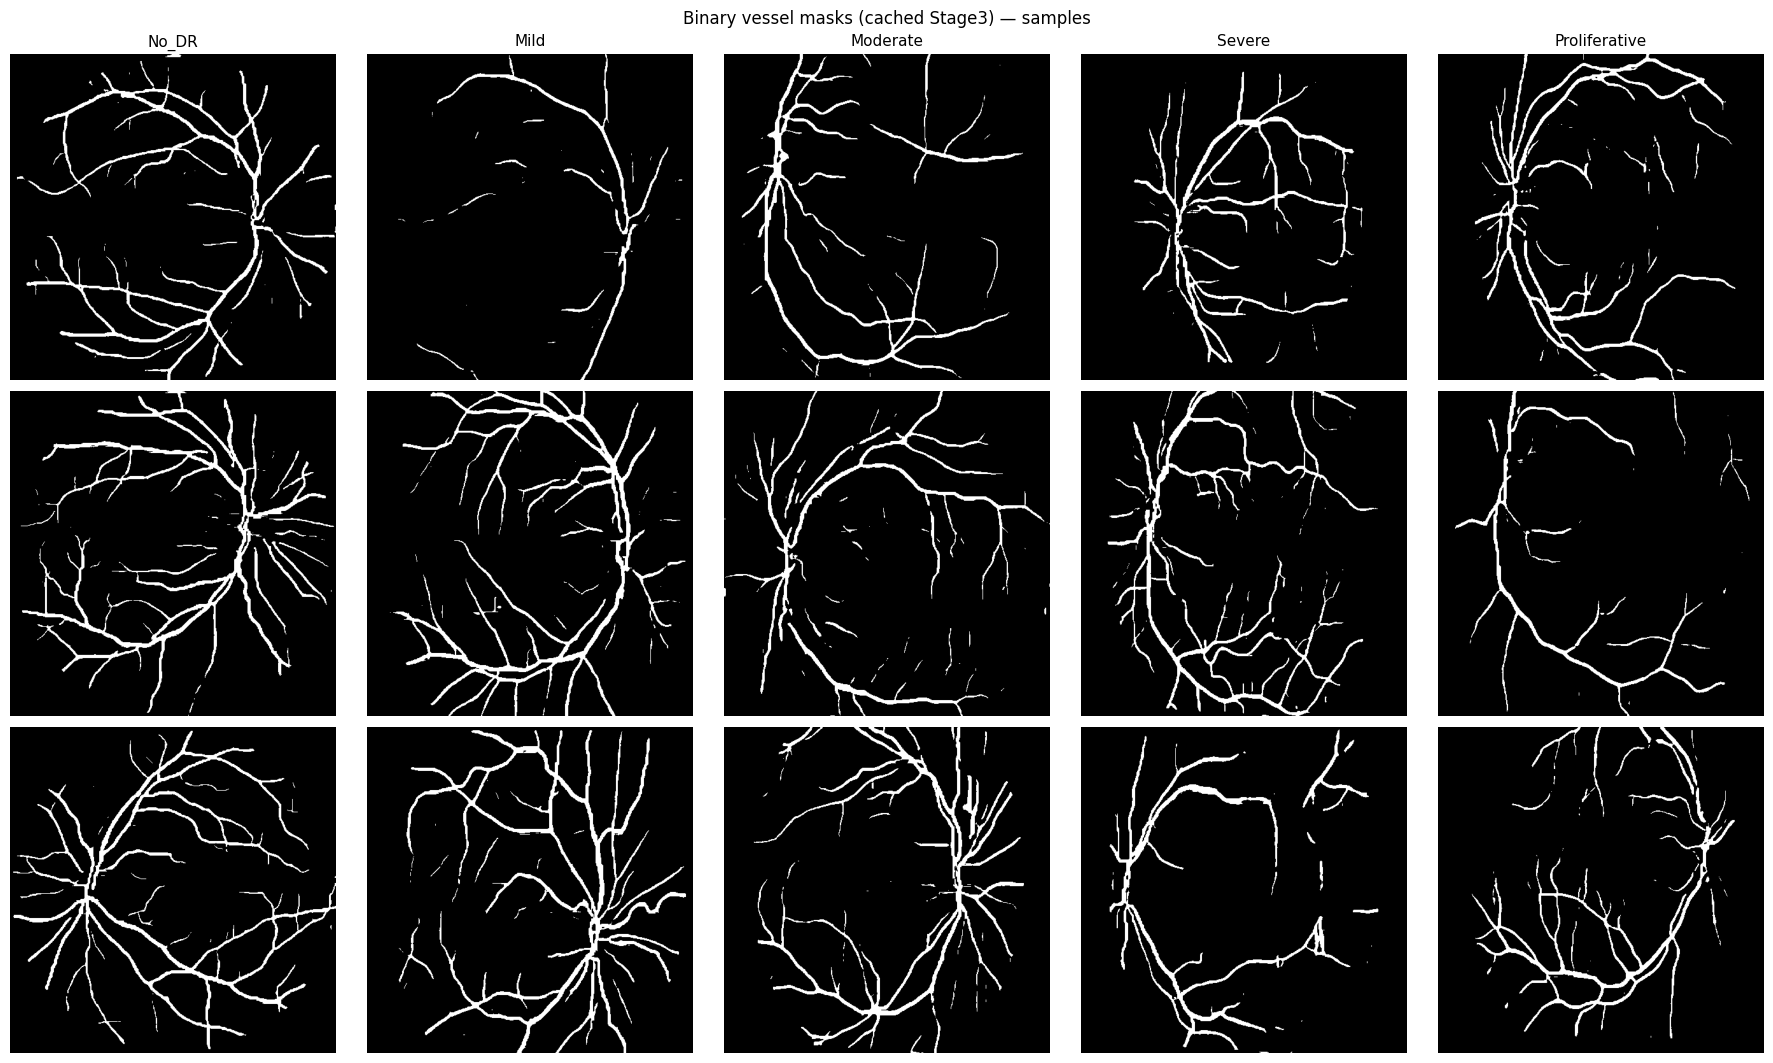

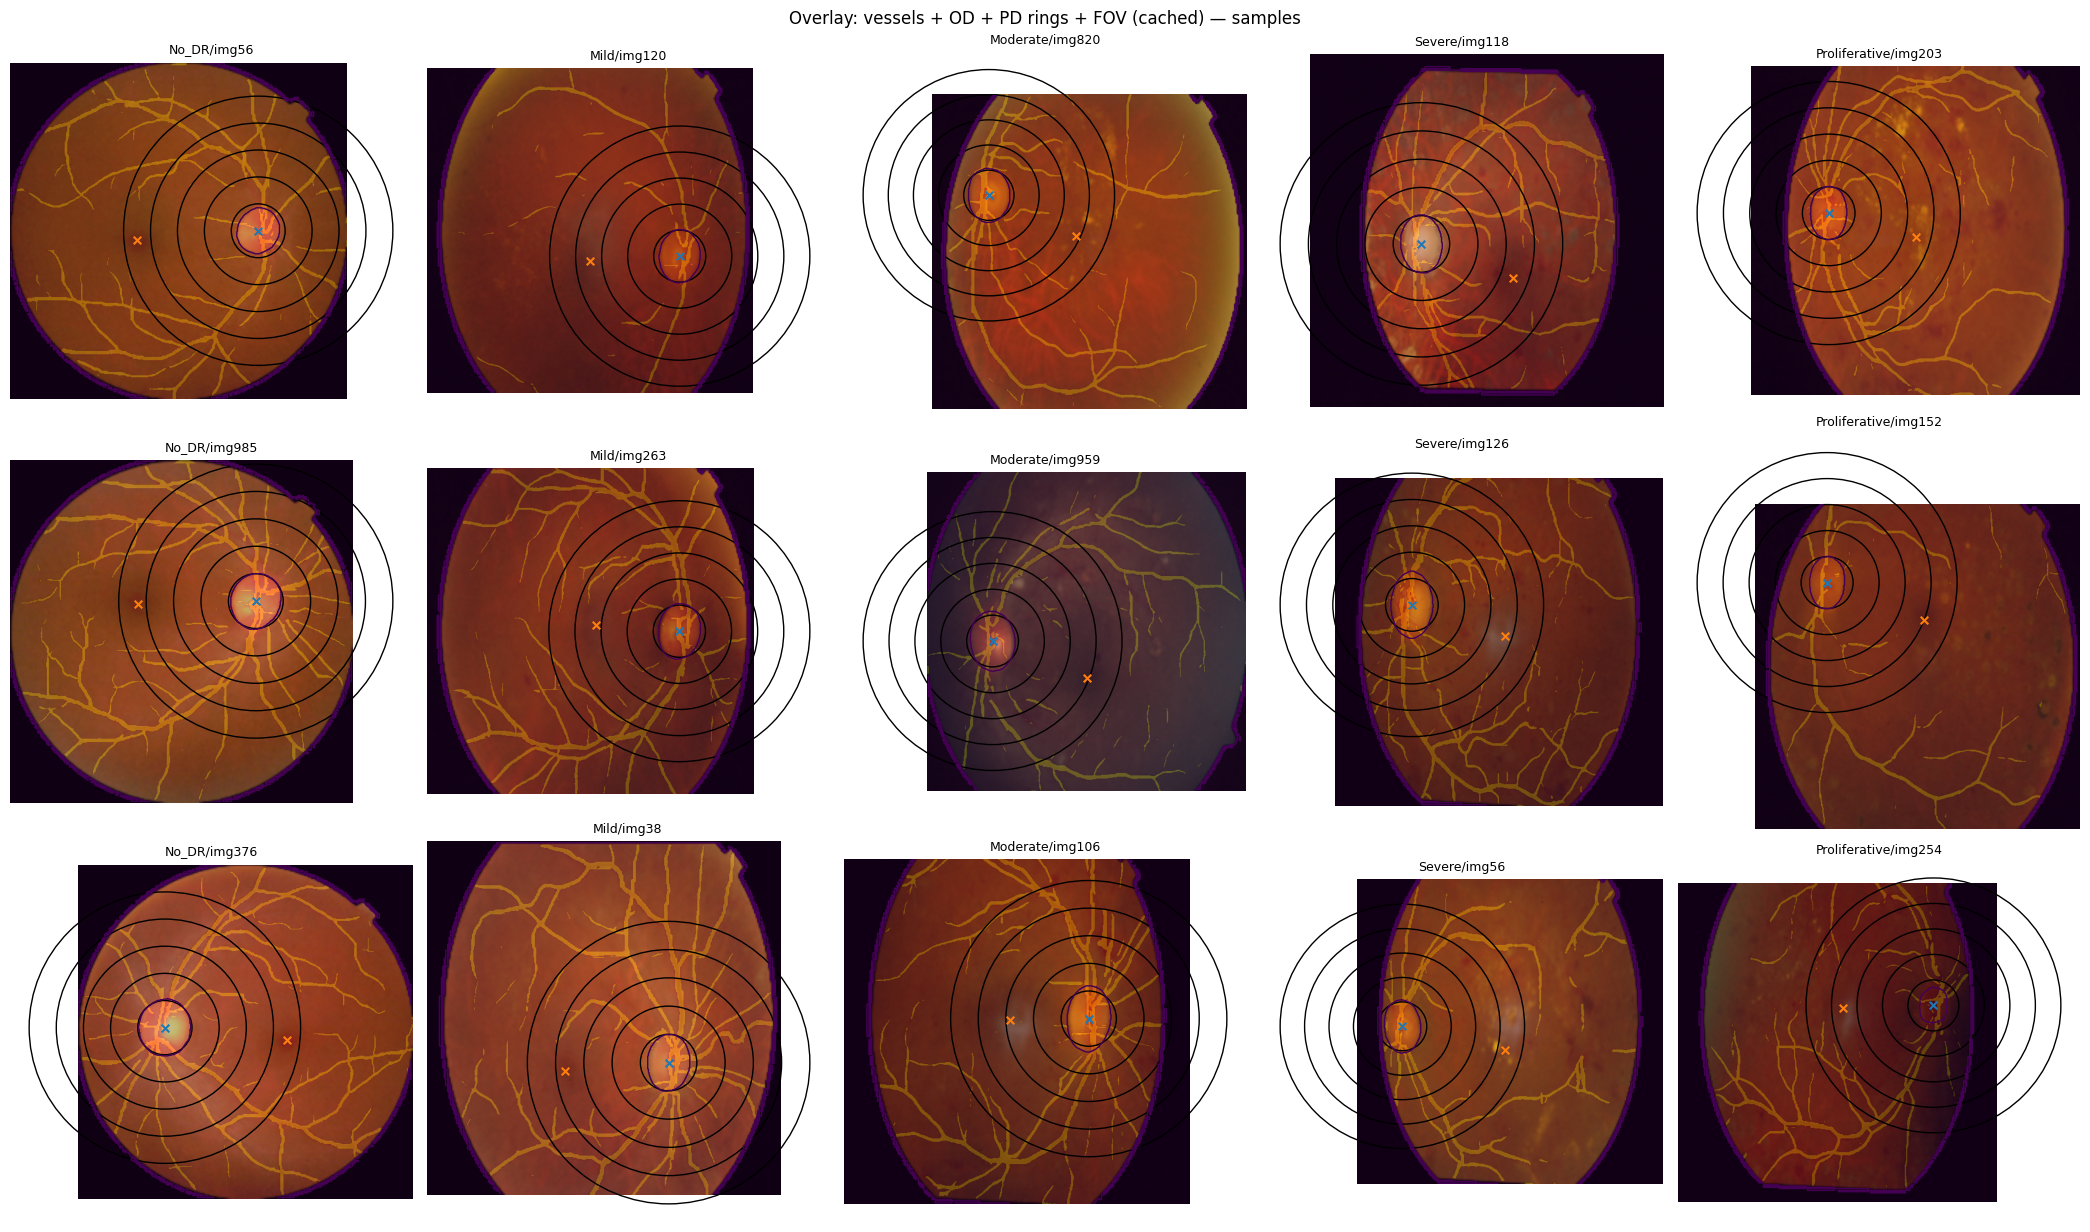

In [10]:
def safe_id(image_id: str) -> str:
    return image_id.replace("/", "__").replace("\\", "__")

def load_rgb_iso(image_id):
    return np.load(STAGE1_ROOT / safe_id(image_id) / "rgb_iso.npy")

def load_fov(image_id):
    p = STAGE1_ROOT / safe_id(image_id) / "fov_1hw.npy"
    return (np.load(p)[0] > 0.5) if p.exists() else None

def load_disc_mask(image_id):
    p = STAGE2_ROOT / safe_id(image_id) / "disc_mask.npy"
    return (np.load(p) > 0) if p.exists() else None

def load_od_json(image_id):
    return json.loads((STAGE2_ROOT / safe_id(image_id) / "od.json").read_text())

def load_fovea_center(image_id):
    p = STAGE2_ROOT / safe_id(image_id) / "fovea.json"
    if not p.exists():
        return None
    return json.loads(p.read_text()).get("fovea_center_yx", None)

def load_prob(image_id):
    return np.load(STAGE3_ROOT / safe_id(image_id) / "prob_map.npy").astype(np.float32)

def pred_mask(image_id, thr=0.5):
    prob = load_prob(image_id)
    m = (prob >= thr)
    f = load_fov(image_id)
    if f is not None:
        m = m & f
    return m

def draw_overlay_cached(ax, image_id, thr=0.5, ring_bounds=(0.5,1.0,1.5,2.0,2.5)):
    import matplotlib.patches as patches

    rgb = load_rgb_iso(image_id)
    fov = load_fov(image_id)
    disc = load_disc_mask(image_id)
    od = load_od_json(image_id)
    fv = load_fovea_center(image_id)
    m  = pred_mask(image_id, thr=thr)

    cy, cx = od["center_yx"]
    PD = float(od["PD_px"])

    ax.imshow(rgb)
    if fov is not None:
        ax.contour(fov.astype(float), levels=[0.5], linewidths=1.0)
    if disc is not None:
        ax.contour(disc.astype(float), levels=[0.5], linewidths=1.0)

    # vessel mask overlay
    ax.imshow(m.astype(float), alpha=0.25)

    # PD rings
    for rPD in ring_bounds:
        circ = patches.Circle((cx, cy), radius=rPD*PD, fill=False, linewidth=1.0)
        ax.add_patch(circ)

    ax.scatter([cx],[cy], s=30, marker="x")  # OD center
    if fv is not None:
        fy, fx = fv
        ax.scatter([fx],[fy], s=30, marker="x")  # fovea

    ax.set_title(image_id, fontsize=9)
    ax.axis("off")


# ---- pick samples per group ----
random.seed(7)
SAMPLES_PER_GROUP = 3
samples = {}
for g in GROUP_ORDER:
    ids = [o["image_id"] for o in outs_by_group[g]]
    random.shuffle(ids)
    samples[g] = ids[:SAMPLES_PER_GROUP]

# ---- binary mask grid ----
rows = SAMPLES_PER_GROUP
cols = len(GROUP_ORDER)
fig, axes = plt.subplots(rows, cols, figsize=(3.6*cols, 3.6*rows))
for c, g in enumerate(GROUP_ORDER):
    for r in range(rows):
        ax = axes[r, c]
        if r < len(samples[g]):
            mid = samples[g][r]
            ax.imshow(pred_mask(mid).astype(float), cmap="gray", vmin=0, vmax=1)
            if r == 0:
                ax.set_title(g, fontsize=11)
        ax.axis("off")
plt.suptitle("Binary vessel masks (cached Stage3) — samples", y=0.98)
plt.tight_layout()
plt.show()


# ---- overlay grid ----
fig, axes = plt.subplots(rows, cols, figsize=(4.2*cols, 4.2*rows))
for c, g in enumerate(GROUP_ORDER):
    for r in range(rows):
        ax = axes[r, c]
        if r < len(samples[g]):
            draw_overlay_cached(ax, samples[g][r])
        else:
            ax.axis("off")
plt.suptitle("Overlay: vessels + OD + PD rings + FOV (cached) — samples", y=0.98)
plt.tight_layout()
plt.show()


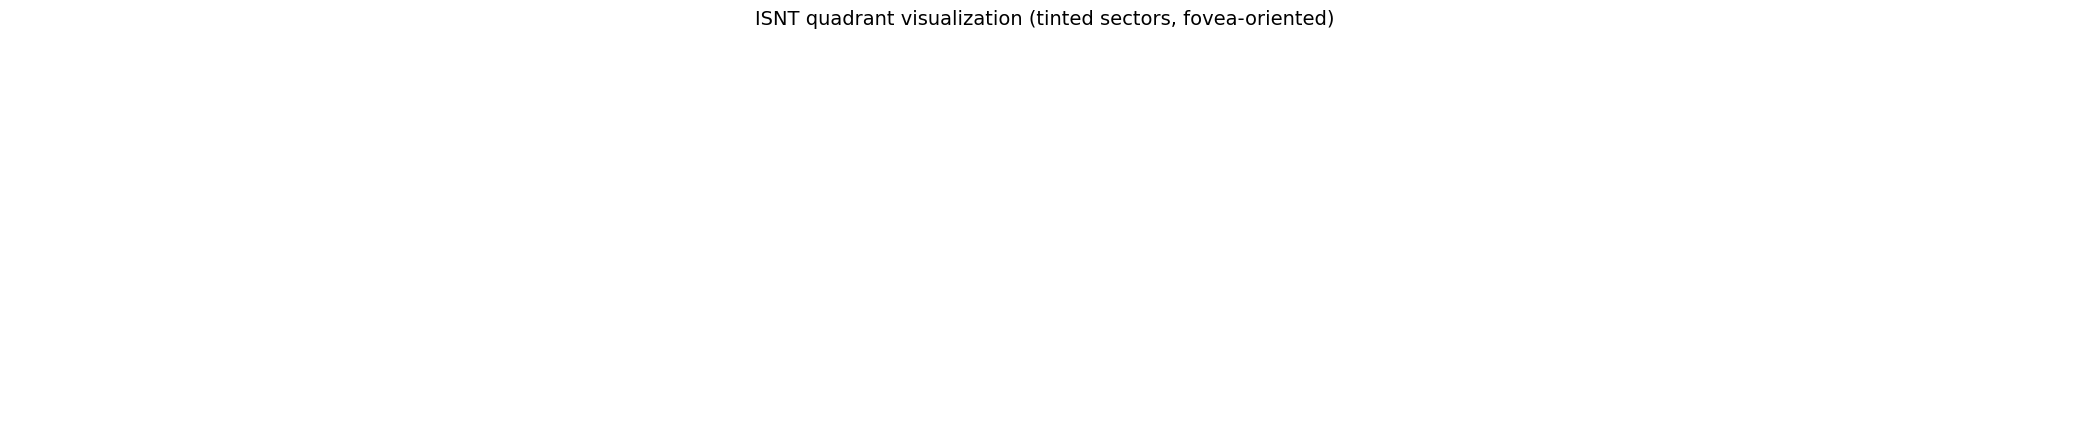

In [15]:
# ============================================================
# ISNT QUADRANT VISUALIZATION GRID (cached pipeline outputs)
# - Shows >=3 images per disease class
# - Uses cached "isnt_geo" + "rgb_iso"/image + quadrant masks
# - Draws tinted ISNT sectors + boundary lines + labels
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects

# ----------------------------
# 1) Label + drawing utilities
# ----------------------------
def _label(ax, x, y, txt, fs=12):
    pe = [patheffects.withStroke(linewidth=3, foreground="black", alpha=0.6)]
    t = ax.text(x, y, txt, color="white", fontsize=fs, ha="center", va="center")
    t.set_path_effects(pe)

def _centroid(mask_bool, fallback_xy):
    ys, xs = np.nonzero(mask_bool)
    if ys.size == 0:
        return fallback_xy
    return (float(xs.mean()), float(ys.mean()))

def draw_isnt_quadrants_overlay(
    ax,
    img_rgb,             # HxWx3
    masks_dict,          # {"I":bool, "S":bool, "N":bool, "T":bool}
    disc_yx,             # (cy,cx)
    fovea_yx,            # (fy,fx)
    *,
    alpha=0.22,
    show_boundaries=True,
    show_markers=True,
    show_labels=True,
    title=None
):
    ax.imshow(img_rgb)
    ax.axis("off")

    # sector tint colors (RGBA)
    colors = {
        "I": (0.10, 0.70, 1.00, alpha),  # cyan
        "S": (1.00, 0.25, 0.65, alpha),  # magenta
        "N": (1.00, 0.90, 0.10, alpha),  # yellow
        "T": (0.10, 0.85, 0.35, alpha),  # green
    }

    # RGBA overlay
    overlay = np.zeros((img_rgb.shape[0], img_rgb.shape[1], 4), dtype=float)
    for k, m in masks_dict.items():
        if m is None:
            continue
        m = np.asarray(m).astype(bool)
        if m.shape[:2] != img_rgb.shape[:2]:
            # defensive: skip mismatched masks
            continue
        overlay[m, :3] = colors[k][:3]
        overlay[m, 3]  = colors[k][3]
    ax.imshow(overlay)

    cy, cx = disc_yx
    fy, fx = fovea_yx

    # boundaries (45° lines around the fovea-disc axis)
    if show_boundaries:
        v = np.array([fx - cx, fy - cy], dtype=float)
        v /= (np.linalg.norm(v) + 1e-9)
        p = np.array([-v[1], v[0]], dtype=float)
        H, W = img_rgb.shape[:2]
        L = float(max(H, W))

        d1 = ( v + p) / np.sqrt(2)
        d2 = (-v + p) / np.sqrt(2)
        d3 = (-v - p) / np.sqrt(2)
        d4 = ( v - p) / np.sqrt(2)

        for d in (d1, d2, d3, d4):
            ax.plot([cx - L*d[0], cx + L*d[0]],
                    [cy - L*d[1], cy + L*d[1]],
                    color="white", lw=1)

    # markers
    if show_markers:
        ax.scatter([cx], [cy], s=50, c="yellow", marker="x", linewidths=1.5)  # disc
        ax.scatter([fx], [fy], s=50, c="cyan",   marker="x", linewidths=1.5)  # fovea

    # labels per quadrant via centroid
    if show_labels:
        fallback_xy = (float(cx), float(cy))
        for key, name in (("T","Temporal"), ("N","Nasal"), ("S","Superior"), ("I","Inferior")):
            if key not in masks_dict or masks_dict[key] is None:
                continue
            x_, y_ = _centroid(np.asarray(masks_dict[key]).astype(bool), fallback_xy)
            _label(ax, x_, y_, name, fs=12)

    if title:
        ax.set_title(title, fontsize=10)


# ----------------------------------------
# 2) Pick N cached examples per disease
# ----------------------------------------
# Expectation: you already have cached outputs per class, e.g.:
#   outs_no, outs_mild, outs_mod, outs_sev, outs_prolif
# OR a dict like: outs_by_group = {"No_DR": [...], ...}
#
# Each out should contain:
#   out["isnt_geo"] with keys: "rgb_iso", "isnt_masks", "disc_center_yx", "fovea_yx"
# And/or out["rgb_iso"] at top-level (fallback).

N_PER_GROUP = 3


# pick first N with valid isnt_geo
picked = {}
for gname, outs in outs_by_group.items():
    keep = []
    for o in outs:
        geo = o.get("isnt_geo", None)
        if isinstance(geo, dict) and geo.get("isnt_masks") is not None and geo.get("disc_center_yx") is not None:
            keep.append(o)
        if len(keep) >= N_PER_GROUP:
            break
    picked[gname] = keep

# ----------------------------------------
# 3) Draw grid: rows = samples, cols = groups
# ----------------------------------------
group_names = list(outs_by_group.keys())
n_cols = len(group_names)
n_rows = max(len(picked[g]) for g in group_names) if group_names else 0
n_rows = max(n_rows, 1)

FIGSIZE = (4.2 * n_cols, 4.2 * n_rows)   # same sizing style you used for overlays
fig, axes = plt.subplots(n_rows, n_cols, figsize=FIGSIZE)

if n_rows == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes)

for c, gname in enumerate(group_names):
    outs = picked.get(gname, [])
    for r in range(n_rows):
        ax = axes[r, c]
        if r >= len(outs):
            ax.axis("off")
            continue

        o = outs[r]
        geo = o.get("isnt_geo") or {}

        # image: prefer geo["rgb_iso"] then out["rgb_iso"]
        img = geo.get("rgb_iso", None)
        if img is None:
            img = o.get("rgb_iso", None)

        masks = geo.get("isnt_masks", None)
        disc  = geo.get("disc_center_yx", None)
        fovea = geo.get("fovea_yx", None)

        if img is None or masks is None or disc is None or fovea is None:
            ax.axis("off")
            ax.set_title(f"{gname} (missing geo)", fontsize=9)
            continue

        title = gname if r == 0 else None
        draw_isnt_quadrants_overlay(
            ax,
            img_rgb=np.asarray(img),
            masks_dict=masks,
            disc_yx=disc,
            fovea_yx=fovea,
            alpha=0.22,
            show_boundaries=True,
            show_markers=True,
            show_labels=True,
            title=title
        )

plt.suptitle("ISNT quadrant visualization (tinted sectors, fovea-oriented)", y=0.995, fontsize=14)
plt.tight_layout()
plt.show()


No_DR: found 3 image_ids -> ['No_DR/img1', 'No_DR/img10', 'No_DR/img100']


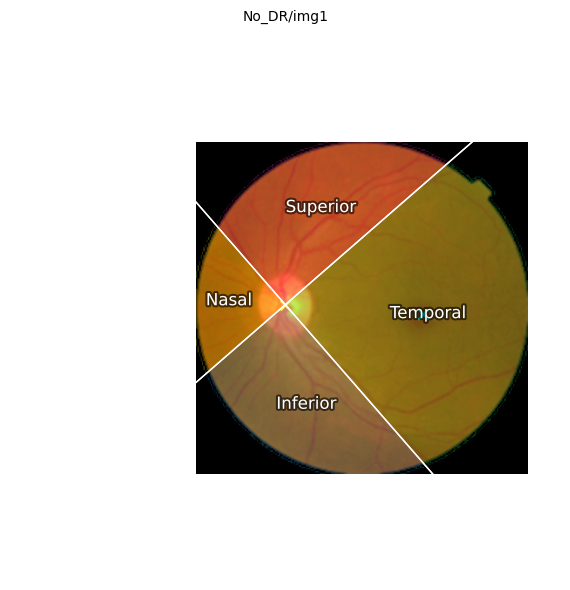

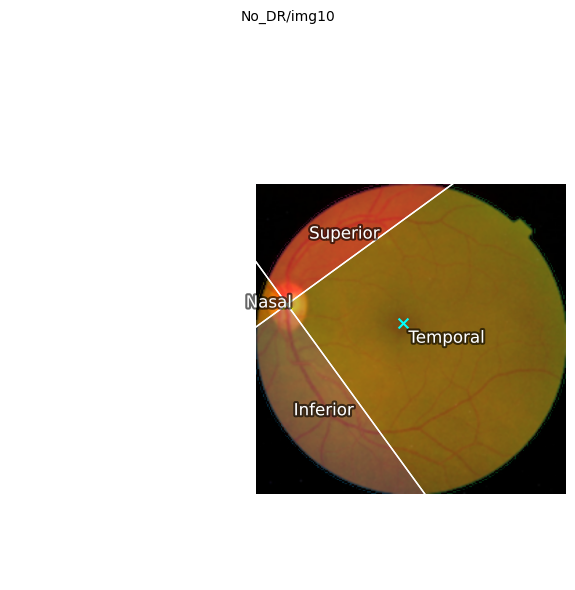

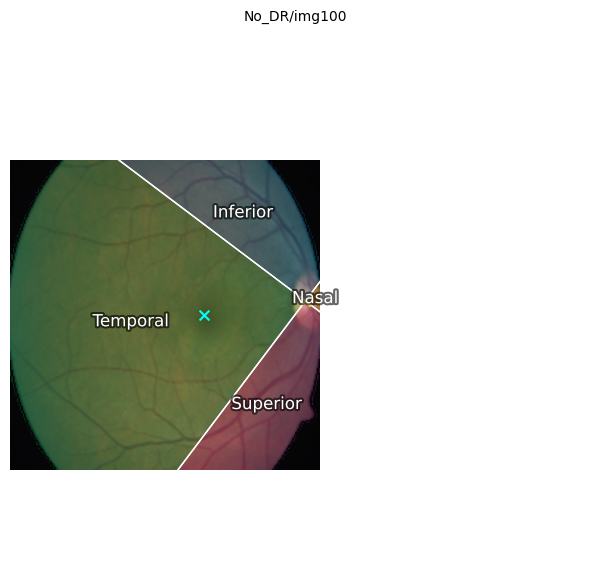

Mild: found 3 image_ids -> ['Mild/img1', 'Mild/img10', 'Mild/img100']


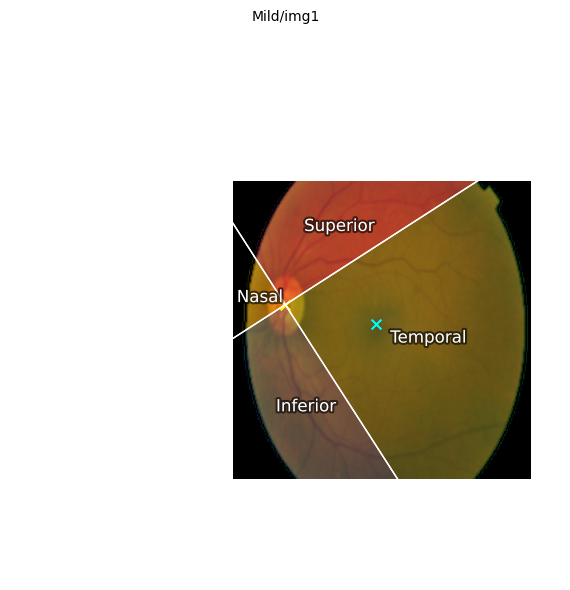

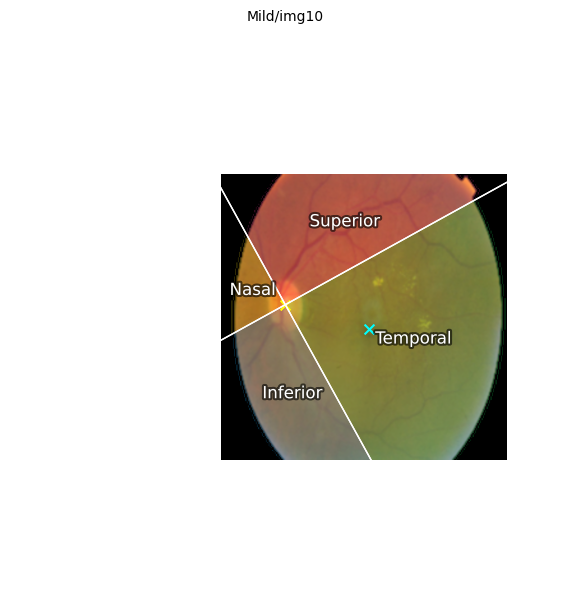

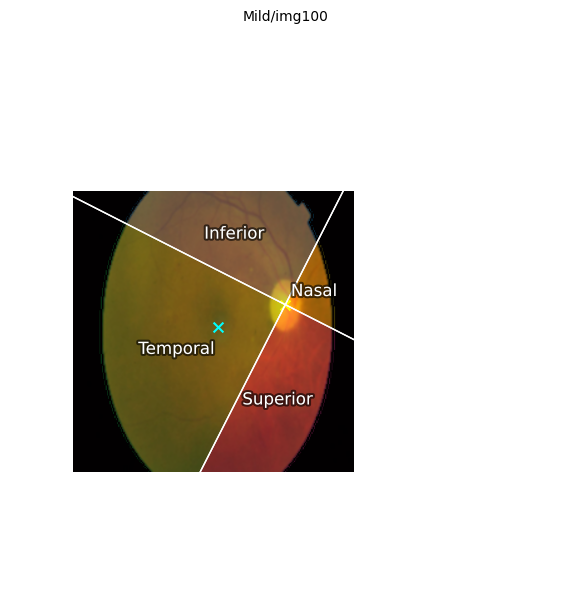

Moderate: found 3 image_ids -> ['Moderate/img1', 'Moderate/img10', 'Moderate/img100']


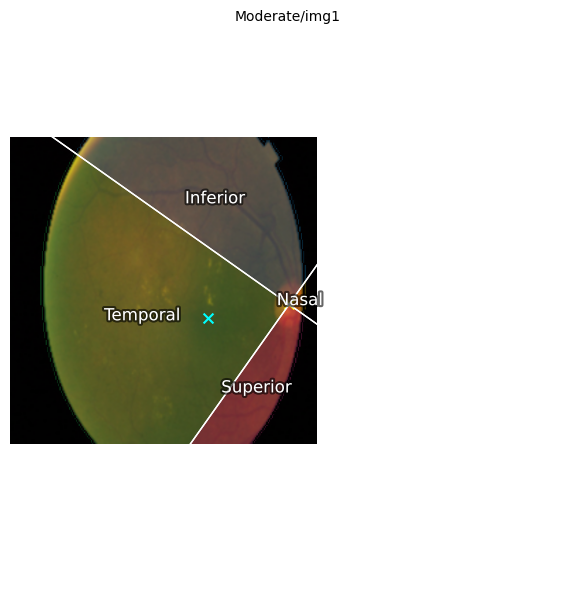

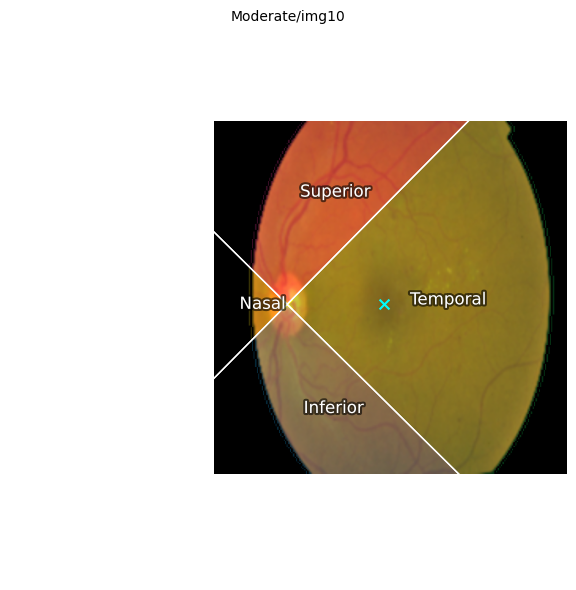

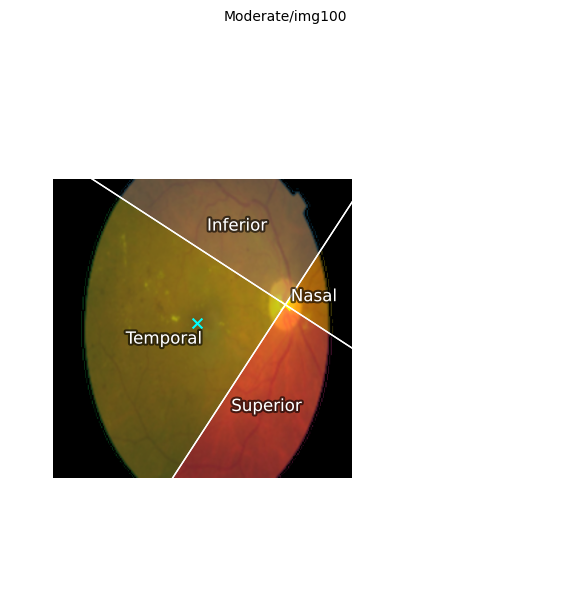

Severe: found 3 image_ids -> ['Severe/img1', 'Severe/img10', 'Severe/img100']


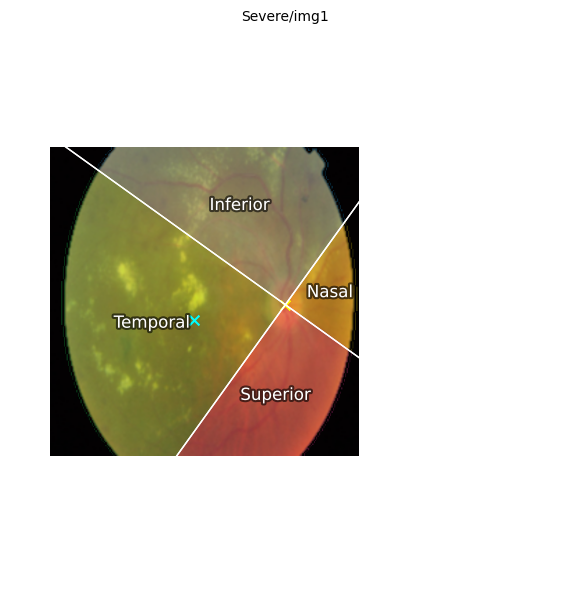

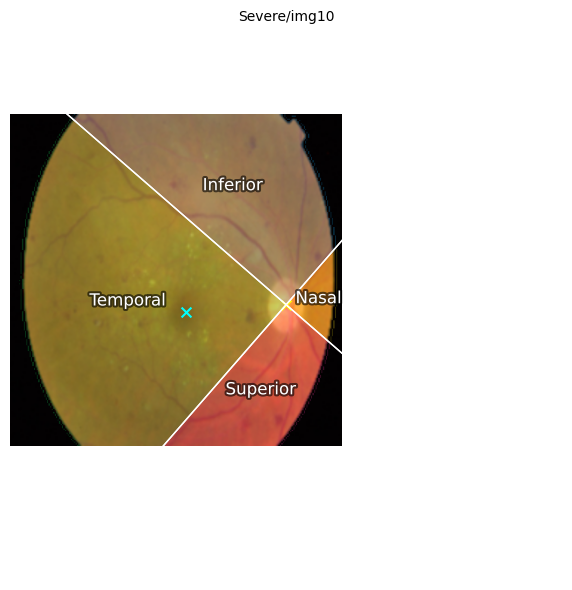

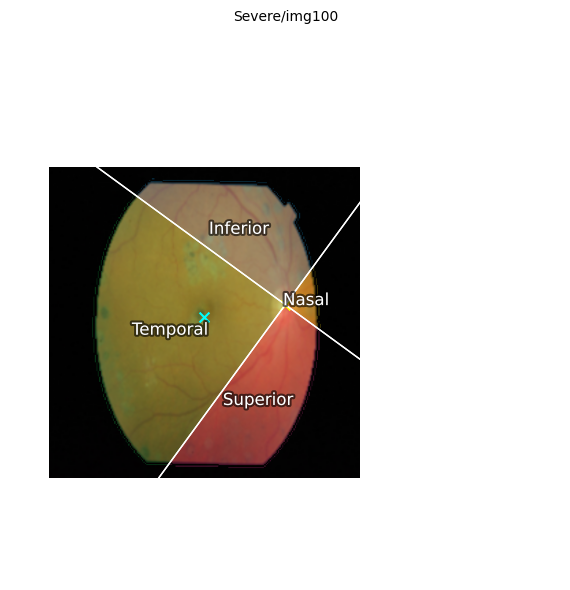

Proliferative: found 3 image_ids -> ['Proliferative/img1', 'Proliferative/img10', 'Proliferative/img100']


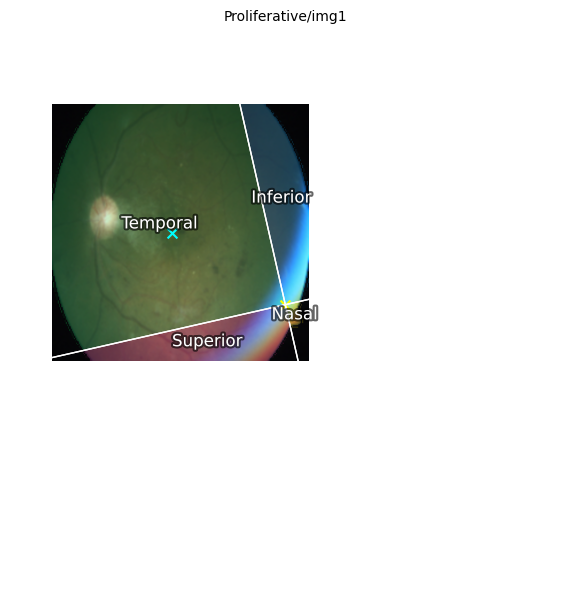

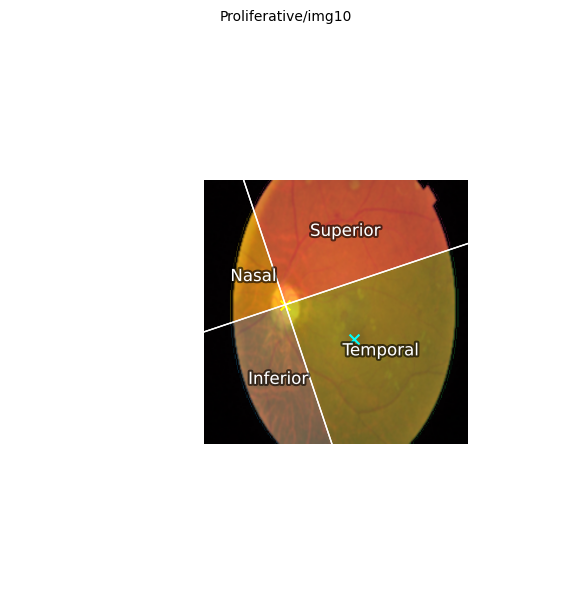

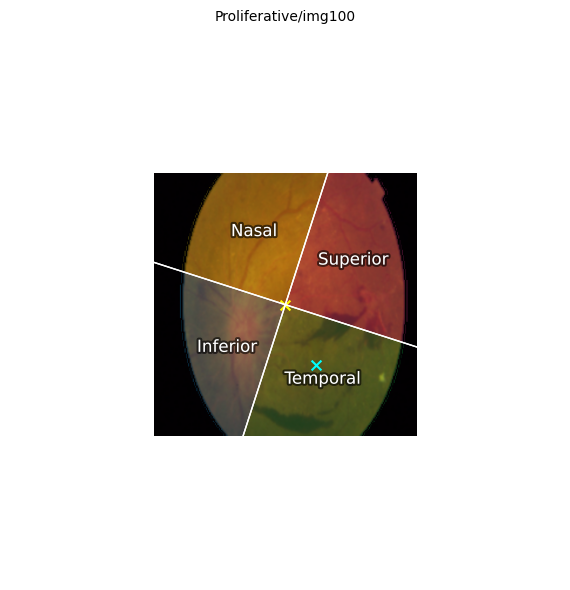

Total plotted: 15


In [18]:
import numpy as np, json, matplotlib.pyplot as plt
from pathlib import Path
from src.retina_biomarkers.isnt_quadrants import draw_isnt_quadrants, isnt_quadrants_masks

# =========================
# EDIT THESE (same as yours)
# =========================
CACHE_ROOT = Path("../../outputs/aptos_cache")
RUN_ID_STAGE1 = "aptos2019_stage1_03b974d569"
RUN_ID_STAGE2 = "aptos2019_stage2_793ded0a61"

GROUP_ORDER = ["No_DR", "Mild", "Moderate", "Severe", "Proliferative"]
N_PER_GROUP = 3
# =========================

def safe_id(s: str) -> str:
    return s.replace("/", "__")

def unsafe_id(s: str) -> str:
    return s.replace("__", "/")

def _get_image_ids_for_group(g: str, n: int):
    """
    Prefer using outs_by_group (from your stage4 biomarker loads).
    Fallback: scan stage1 cache folders and reconstruct image_id from safe_id.
    """
    ids = []

    # --- preferred: use your already-built outs_by_group ---
    if "outs_by_group" in globals() and isinstance(outs_by_group, dict):
        arr = outs_by_group.get(g, [])
        for o in arr:
            image_id = o.get("image_id", None) if isinstance(o, dict) else None
            if image_id and isinstance(image_id, str) and image_id.startswith(g + "/"):
                ids.append(image_id)
            if len(ids) >= n:
                break

    # --- fallback: scan stage1 cache dirs ---
    if len(ids) < n:
        stage1_dir = CACHE_ROOT / RUN_ID_STAGE1 / "stage1"
        if stage1_dir.exists():
            for d in sorted(stage1_dir.iterdir()):
                if not d.is_dir():
                    continue
                image_id = unsafe_id(d.name)
                if image_id.startswith(g + "/"):
                    ids.append(image_id)
                if len(ids) >= n:
                    break

    return ids[:n]

def _load_cached_isnt(image_id: str):
    """
    Loads rgb, fov, od center, fovea center from cached stage1/stage2,
    computes ISNT masks, returns everything needed for drawing.
    """
    s1 = CACHE_ROOT / RUN_ID_STAGE1 / "stage1" / safe_id(image_id)
    s2 = CACHE_ROOT / RUN_ID_STAGE2 / "stage2" / safe_id(image_id)

    # stage1
    rgb_path = s1 / "rgb_iso.npy"
    fov_path = s1 / "fov_1hw.npy"

    # stage2
    od_path = s2 / "od.json"
    fv_path = s2 / "fovea.json"

    if not rgb_path.exists():
        raise FileNotFoundError(f"Missing {rgb_path}")
    if not fov_path.exists():
        raise FileNotFoundError(f"Missing {fov_path}")
    if not od_path.exists():
        raise FileNotFoundError(f"Missing {od_path}")
    if not fv_path.exists():
        raise FileNotFoundError(f"Missing {fv_path}")

    rgb = np.load(rgb_path)
    fov = (np.load(fov_path)[0] > 0.5)

    od = json.loads(od_path.read_text())
    fv = json.loads(fv_path.read_text())
    fovea_yx = tuple(fv["fovea_center_yx"])
    disc_yx  = tuple(od["center_yx"])

    masks = isnt_quadrants_masks(
        rgb.shape[:2],
        disc_yx,
        fovea_yx=fovea_yx,
        sector_deg=90.0,
        fov=fov
    )

    return rgb, masks, disc_yx, fovea_yx

# =========================
# PLOT: 3 per disease, each as its own figure
# =========================
total_plotted = 0

for g in GROUP_ORDER:
    image_ids = _get_image_ids_for_group(g, N_PER_GROUP)
    print(f"{g}: found {len(image_ids)} image_ids -> {image_ids}")

    for image_id in image_ids:
        try:
            rgb, masks, disc_yx, fovea_yx = _load_cached_isnt(image_id)

            fig, ax = plt.subplots(1, 1, figsize=(6, 6))
            draw_isnt_quadrants(ax, rgb, masks, disc_yx, fovea_yx)
            ax.set_title(image_id, fontsize=10)
            plt.tight_layout()
            plt.show()

            total_plotted += 1

        except Exception as e:
            print(f"[warn] {image_id}: {e}")

print("Total plotted:", total_plotted)
